In [1]:
import random
import numpy as np
import tensorflow as tf
import torch
import os

seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
torch.manual_seed(seed_value)
torch.cuda.manual_seed_all(seed_value)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
import gdown
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, ttest_ind

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             roc_auc_score, RocCurveDisplay,
                             ConfusionMatrixDisplay)

from xgboost import XGBClassifier

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import shap
import joblib

In [3]:
# Links to the files
url1 = "https://drive.google.com/file/d/1NBL96uw95T5nhH2_bncc-jvVEOp6_Mjn/view?usp=drive_link" # cardiac_failure_processed.csv
url2 = "https://drive.google.com/file/d/1_pcIRUWpHoUNkiHcDK01HlLkOOMXi9hn/view?usp=drive_link" # cardio_base.csv
url3 = "https://drive.google.com/file/d/1mopCa200spbeFRFpkr_ppuLbqsdl0BaR/view?usp=drive_link" # heart_processed.csv

# Dictionary of the files and their Google Drive IDs
data_files = {
    'cardiac_failure_processed.csv': '1NBL96uw95T5nhH2_bncc-jvVEOp6_Mjn',
    'cardio_base.csv': '1_pcIRUWpHoUNkiHcDK01HlLkOOMXi9hn',
    'heart_processed.csv': '1mopCa200spbeFRFpkr_ppuLbqsdl0BaR',
}

# Download each one if it doesn't exist
for filename, file_id in data_files.items():
  if not os.path.exists(filename):
    print(f"Downloading {filename}...")
    url = f'https://drive.google.com/uc?id={file_id}'
    gdown.download(url, filename, quiet=False)

# Now load them all with the correct separators
# Note: Use the separators you discovered (semicolons or commas)
cardiac_fail = pd.read_csv('cardiac_failure_processed.csv', sep=None, engine='python', header=0)
cardiac = pd.read_csv('cardio_base.csv', sep=None, engine='python', header=0)
heart = pd.read_csv('heart_processed.csv', sep=None, engine='python', header=0)

Downloading...
From: https://drive.google.com/uc?id=1NBL96uw95T5nhH2_bncc-jvVEOp6_Mjn
To: /content/cardiac_failure_processed.csv
100%|██████████| 4.26M/4.26M [00:00<00:00, 30.6MB/s]


Downloading...
From: https://drive.google.com/uc?id=1_pcIRUWpHoUNkiHcDK01HlLkOOMXi9hn
To: /content/cardio_base.csv
100%|██████████| 2.94M/2.94M [00:00<00:00, 180MB/s]


Downloading...
From: https://drive.google.com/uc?id=1mopCa200spbeFRFpkr_ppuLbqsdl0BaR
To: /content/heart_processed.csv
100%|██████████| 67.4k/67.4k [00:00<00:00, 26.1MB/s]


In [4]:
print("cardiac shape:", cardiac.shape)
print("heart shape:  ", heart.shape)

cardiac shape: (70000, 13)
heart shape:   (918, 16)


In [5]:
cardiac_fail.head() # So this is not a good data

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0,0.588076,2,168,62.0,110,80,1,1,0,0,1,0
1,1,1,0.730159,1,156,85.0,140,90,3,1,0,0,1,1
2,2,2,0.624003,1,165,64.0,130,70,3,1,0,0,0,1
3,3,3,0.528455,2,169,82.0,150,100,1,1,0,0,1,1
4,4,4,0.516918,1,156,56.0,100,60,1,1,0,0,0,0


In [6]:
cardiac.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [7]:
# See if there are missing values
print("--- cardiac missing values ---")
print(cardiac.isnull().sum())

--- cardiac missing values ---
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


In [8]:
cardiac.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


For cardiac dataset, based on common medical datasets:

- Age: The age of the patient in days
- Gender: We’ll check if 1 is women or not using their average height
- ap_hi / ap_lo: Systolic and Diastolic blood pressure
- Cholesterol / Gluc: 1 = Normal, 2 = Above Normal, 3 = Well Above Normal
- Smoke / Alco / Active: 0 = No, 1 = Yes
- Cardio (Target): 0 = No heart disease, 1 = Has heart disease

In [9]:
# Check the impossible blood pressure values
print("ap_hi max:", cardiac['ap_hi'].max())
print("ap_lo max:", cardiac['ap_lo'].max())

# Check ID gaps: If this is True, there are gaps in the ID sequence, which explains the maximum value of ID
print("ID gaps:", cardiac['id'].nunique() != (cardiac['id'].max() - cardiac['id'].min() + 1))

# cardiac_fail has age pre-scaled - we use cardiac (raw) and do our own preprocessing
print("\ncardiac_fail age sample:", cardiac_fail['age'].head())
print("cardiac age sample:     ", cardiac['age'].head())

ap_hi max: 16020
ap_lo max: 11000
ID gaps: True

cardiac_fail age sample: 0    0.588076
1    0.730159
2    0.624003
3    0.528455
4    0.516918
Name: age, dtype: float64
cardiac age sample:      0    18393
1    20228
2    18857
3    17623
4    17474
Name: age, dtype: int64


Cleaning cardiac dataset

We will filter to create a new dataframe (cardiac_clean) that only keeps values that biologically make sense.

In medical terms:
- Age should be realistic (between 0 and 120).
- Blood pressure can't be negative.
- Systolic (ap_hi) should generally be between 60 and 250.
- Diastolic (ap_lo) should generally be between 40 and 150.
- Crucially: ap_hi must be greater than ap_lo.
- BMI below 10 or above 80 is almost always a data entry error.

In [10]:
# Step 1: filter impossible blood pressure values
cardiac_clean = cardiac[
    (cardiac['ap_hi'] > 40) &
    (cardiac['ap_lo'] > 20)  &
    (cardiac['ap_hi'] < 300) &
    (cardiac['ap_lo'] < 200) &
    (cardiac['ap_hi'] > cardiac['ap_lo'])
].copy()

# Step 2: compute BMI and filter impossible body measurements
cardiac_clean['bmi'] = cardiac_clean['weight'] / ((cardiac_clean['height'] / 100) ** 2)
cardiac_clean = cardiac_clean[
    (cardiac_clean['bmi'] > 10) &
    (cardiac_clean['bmi'] < 80)
].copy()

# Step 3: convert age from days to years, filter impossible ages
cardiac_clean['age_years'] = (cardiac_clean['age'] / 365).round()
cardiac_clean = cardiac_clean[
    (cardiac_clean['age_years'] > 0) &
    (cardiac_clean['age_years'] < 120)
].copy()

print(f"Original rows : {len(cardiac)}")
print(f"Cleaned rows  : {len(cardiac_clean)}")
print(f"Rows removed  : {len(cardiac) - len(cardiac_clean)}")

Original rows : 70000
Cleaned rows  : 68642
Rows removed  : 1358


In [11]:
cardiac_clean.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi,age_years
count,68642.000000,68642.000000,68642.000000,68642.000000,68642.000000,68642.000000,68642.000000,68642.000000,68642.000000,68642.000000,68642.000000,68642.000000,68642.000000,68642.000000,68642.000000
mean,49977.867166,19464.637554,1.348650,164.398357,74.110427,126.672751,81.301725,1.364689,1.225780,0.087949,0.053335,0.803386,0.494712,27.464643,53.327321
std,28846.784091,2468.116987,0.476546,7.978666,14.283713,16.691996,9.465569,0.678908,0.571651,0.283223,0.224702,0.397441,0.499976,5.269115,6.767634
min,0.000000,10798.000000,1.000000,91.000000,28.000000,60.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,10.726644,30.000000
25%,25006.250000,17658.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,23.875115,48.000000
50%,50021.500000,19701.500000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,26.346494,54.000000
75%,74873.750000,21324.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,30.119376,58.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,240.000000,182.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,74.380165,65.000000


In [12]:
# Group by gender and find the average height: Lower average height -> that group is female
print(cardiac_clean.groupby('gender')['height'].mean())

gender
1    161.410937
2    169.979484
Name: height, dtype: float64


So we know that gender 1 = female, gender 2 = male.

EDA of cardiac dataset

In [13]:
# Calculate the mean (average) of High Blood Pressure
avg_bp = cardiac_clean['ap_hi'].mean()
print(f"The average BP is: {avg_bp}")

# Create the 'high_bp_risk' column
cardiac_clean['high_bp_risk'] = np.where(cardiac_clean['ap_hi'] > avg_bp, 1, 0)

# See how many people are above average vs below (1=higher, 0=lower)
print(cardiac_clean['high_bp_risk'].value_counts())

The average BP is: 126.67275137670813
high_bp_risk
0    40896
1    27746
Name: count, dtype: int64


In [14]:
print(cardiac_clean['cholesterol'].value_counts())
print(cardiac_clean['gluc'].value_counts())
print(cardiac_clean['alco'].value_counts())
print(cardiac_clean['cardio'].value_counts())

cholesterol
1    51476
2     9299
3     7867
Name: count, dtype: int64
gluc
1    58360
3     5216
2     5066
Name: count, dtype: int64
alco
0    64981
1     3661
Name: count, dtype: int64
cardio
0    34684
1    33958
Name: count, dtype: int64


In [15]:
cat_cols = ['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'gender']

# Risk rate per category value (row-normalized crosstab)
# To answer "What is the risk for someone with level 3 cholesterol?" (risk check)
for col in cat_cols:
  print(f"--- {col} vs cardio (% per row) ---")
  print((pd.crosstab(cardiac_clean[col], cardiac_clean['cardio'], normalize='index') * 100).round(2))
  print()

--- cholesterol vs cardio (% per row) ---
cardio           0      1
cholesterol              
1            56.46  43.54
2            40.38  59.62
3            23.74  76.26

--- gluc vs cardio (% per row) ---
cardio      0      1
gluc                
1       52.44  47.56
2       41.14  58.86
3       38.25  61.75

--- smoke vs cardio (% per row) ---
cardio      0      1
smoke               
0       50.28  49.72
1       53.16  46.84

--- alco vs cardio (% per row) ---
cardio      0      1
alco                
0       50.43  49.57
1       52.34  47.66

--- active vs cardio (% per row) ---
cardio      0      1
active              
0       46.73  53.27
1       51.46  48.54

--- gender vs cardio (% per row) ---
cardio      0      1
gender              
1       50.79  49.21
2       50.04  49.96



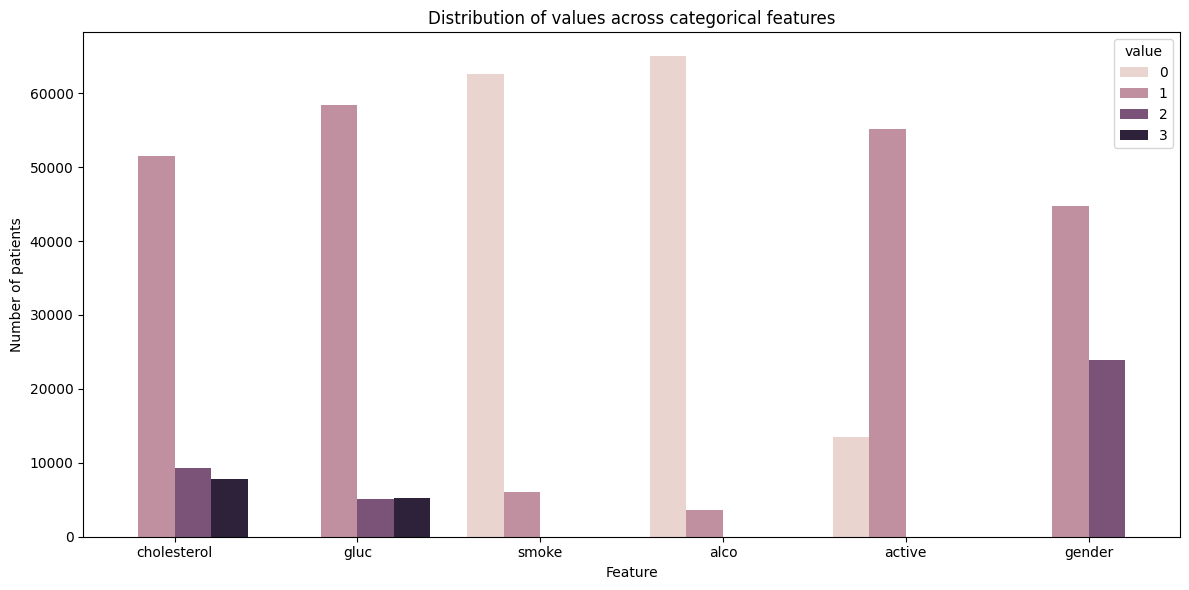

In [16]:
plt.figure(figsize=(12, 6))
sns.countplot(
    x="variable", hue="value",
    data=pd.melt(cardiac_clean[cat_cols])
)
plt.title("Distribution of values across categorical features")
plt.ylabel("Number of patients")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()

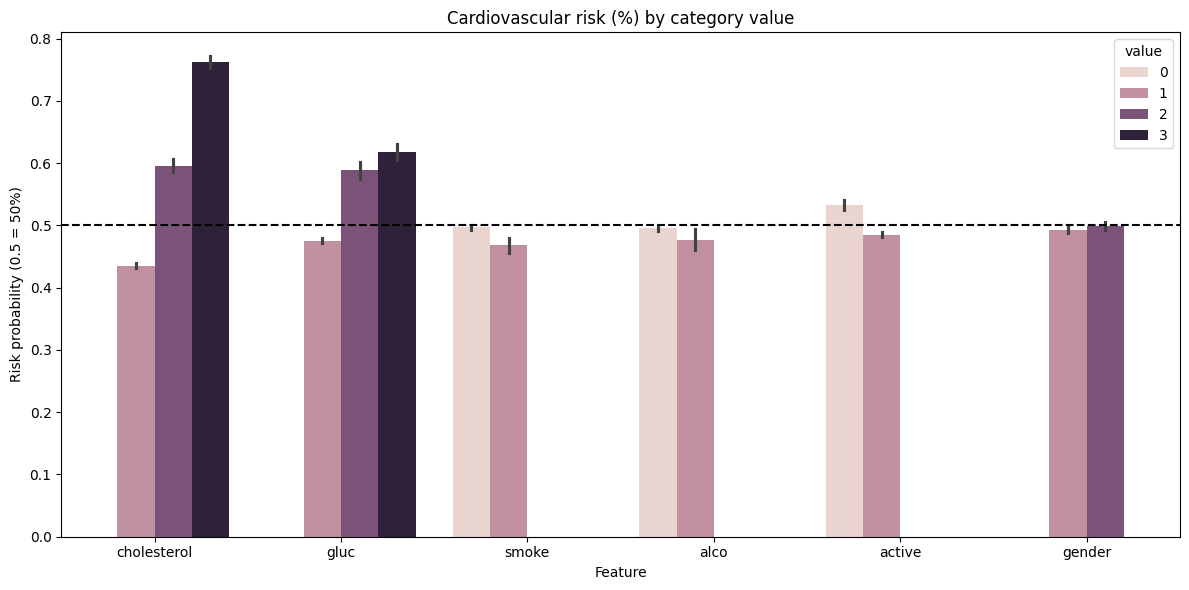

In [17]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x="variable", y="cardio", hue="value",
    data=pd.melt(cardiac_clean, id_vars=['cardio'], value_vars=cat_cols)
)
plt.title("Cardiovascular risk (%) by category value")
plt.ylabel("Risk probability (0.5 = 50%)")
plt.xlabel("Feature")
plt.axhline(0.5, color='black', linestyle='--')
plt.tight_layout()
plt.show()

In [18]:
# Composition of each feature by cardio status (stacked bars)
# To answer: "Among the sick people, what are their cholesterol profiles?"
for col in cat_cols:
  print(f"--- {col} vs cardio counts (% per column) ---")
  print((pd.crosstab(cardiac_clean[f'{col}'], cardiac_clean['cardio'], normalize='columns') * 100).round(2))
  # 'index' means calculate percentages across the rows
  print()

--- cholesterol vs cardio counts (% per column) ---
cardio           0      1
cholesterol              
1            83.79  66.01
2            10.83  16.33
3             5.39  17.67

--- gluc vs cardio counts (% per column) ---
cardio      0      1
gluc                
1       88.24  81.73
2        6.01   8.78
3        5.75   9.49

--- smoke vs cardio counts (% per column) ---
cardio      0      1
smoke               
0       90.75  91.67
1        9.25   8.33

--- alco vs cardio counts (% per column) ---
cardio      0      1
alco                
0       94.48  94.86
1        5.52   5.14

--- active vs cardio counts (% per column) ---
cardio      0      1
active              
0       18.18  21.17
1       81.82  78.83

--- gender vs cardio counts (% per column) ---
cardio      0      1
gender              
1       65.47  64.79
2       34.53  35.21



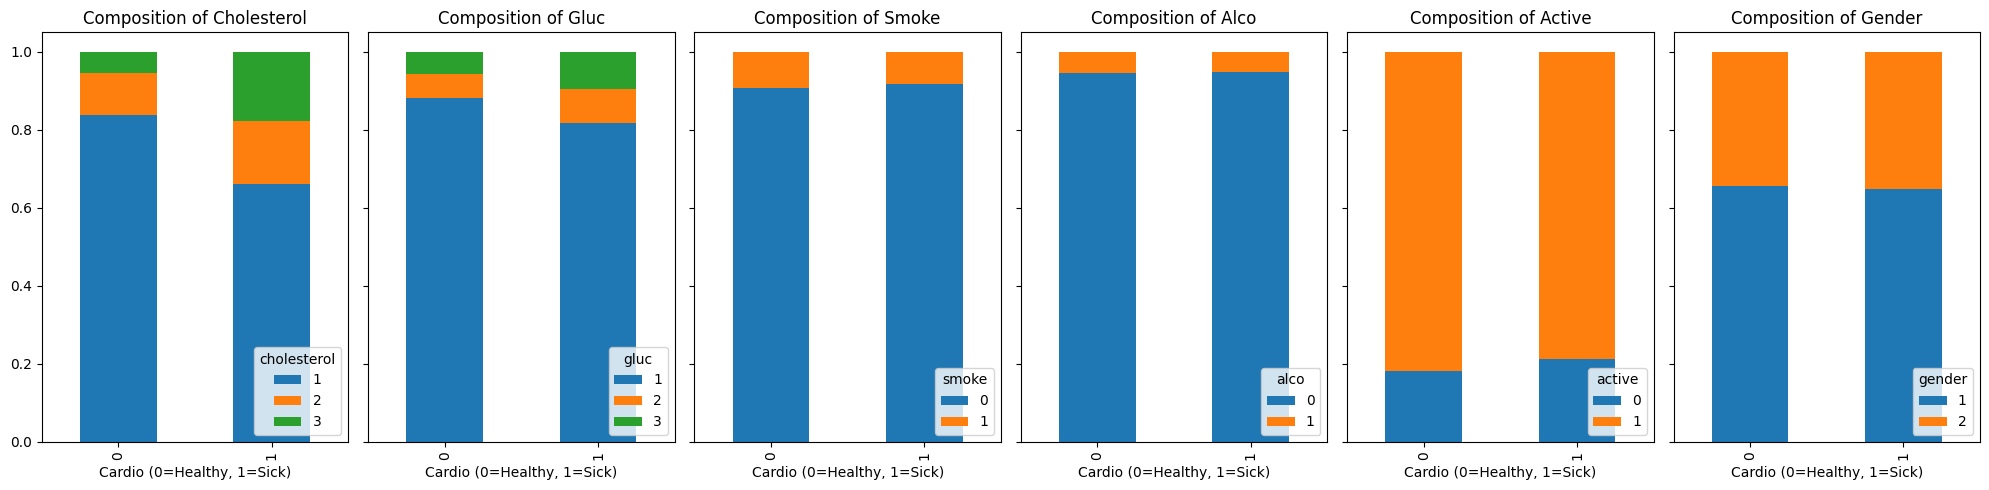

In [19]:
fig, axes = plt.subplots(1, len(cat_cols), figsize=(20, 5), sharey=True)

for i, col in enumerate(cat_cols):
  per_cardio = pd.crosstab(cardiac_clean[col], cardiac_clean['cardio'], normalize='columns')
  per_cardio.T.plot(kind='bar', stacked=True, ax=axes[i])
  axes[i].set_title(f'Composition of {col.capitalize()}')
  axes[i].set_xlabel('Cardio (0=Healthy, 1=Sick)')
  axes[i].legend(title=col, loc='lower right')

plt.tight_layout()
plt.show()

So we definitely see the strong influence of cholesterol and gluc levels on cardiovascular disease.

Checking correlations

Now that the data is clean, we want to see which columns have the strongest relationship with the cardio result.

.corr() calculates the Pearson correlation coefficient (r), where 1 is a perfect positive relationship and 0 is no relationship.

But correlation only measures linear relationships - "as X goes up, does Y go up in a straight line?"

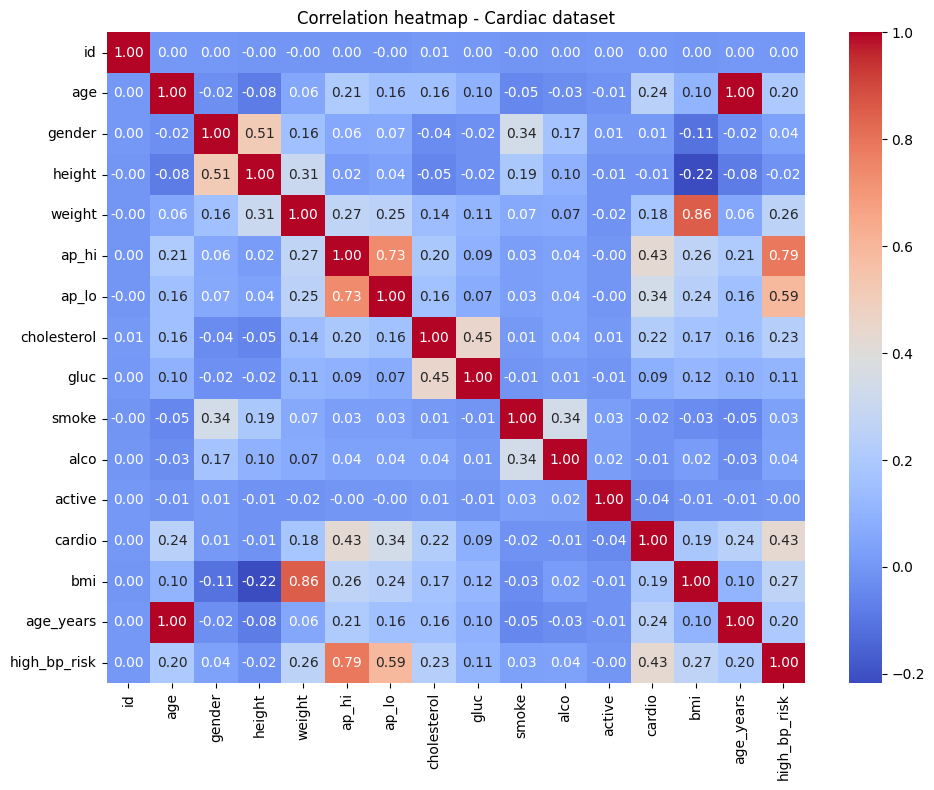


Correlations with target (cardio):
cardio          1.000000
high_bp_risk    0.431531
ap_hi           0.428093
ap_lo           0.339695
age             0.239416
age_years       0.239019
cholesterol     0.221375
bmi             0.188632
weight          0.179947
gluc            0.089557
gender          0.007188
id              0.003791
alco           -0.008577
height         -0.011600
smoke          -0.016314
active         -0.037565
Name: cardio, dtype: float64


In [20]:
# Visualizing the correlation using heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cardiac_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation heatmap - Cardiac dataset")
plt.tight_layout()
plt.show()

print("\nCorrelations with target (cardio):")
print(cardiac_clean.corr()['cardio'].sort_values(ascending=False))

There's clearly 0 correlation with ID.

However, we don't see much relationship with other features neither. It might be better to just count cardio cases based on specific criteria.

In [21]:
# Age and BMI risk analysis

# Age risk
over_50 = cardiac_clean[cardiac_clean['age_years'] >= 50]['cardio'].mean()
under_50 = cardiac_clean[cardiac_clean['age_years'] < 50]['cardio'].mean()
print(f"Risk for age 50+: {over_50:.2%}")
print(f"Risk for age <50: {under_50:.2%}")

# BMI risk
over_30 = cardiac_clean[cardiac_clean['bmi'] >= 30]['cardio'].mean()
under_30 = cardiac_clean[cardiac_clean['bmi'] < 30]['cardio'].mean()
print(f"\nRisk for BMI 30+ (obese): {over_30:.2%}")
print(f"Risk for BMI <30: {under_30:.2%}")

Risk for age 50+: 54.56%
Risk for age <50: 35.61%

Risk for BMI 30+ (obese): 62.49%
Risk for BMI <30: 44.86%


So Age and BMI index matter. Someone who is old/obese is more in danger than those who are young/healthy.

Statistical tests

- For categorical data (e.g. Smoking vs. Cardio): Chi-Square Test

It tells you if being a smoker and having heart disease are independent or related.

- For continuous data (e.g. Age vs. Cardio): T-Test

It checks if the average age of the sick group is significantly different from the healthy group.

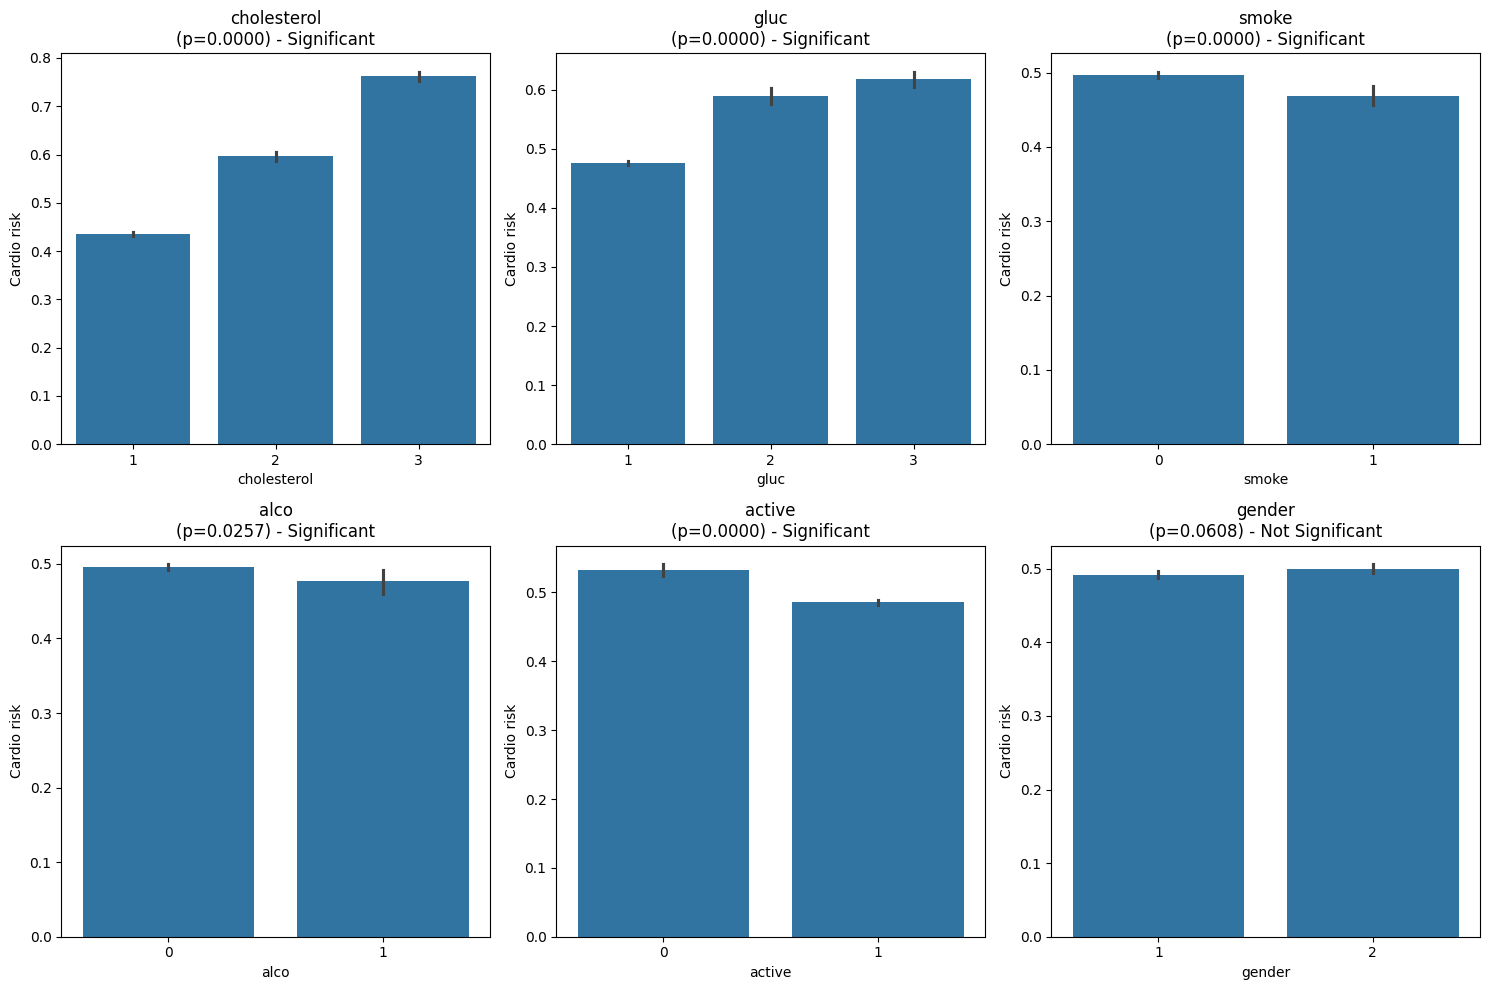

In [22]:
# Chi-square test
plt.figure(figsize=(15, 10))

for i, col in enumerate(cat_cols):
  plt.subplot(2, 3, i+1)
  sns.barplot(x=col, y='cardio', data=cardiac_clean)

  contingency = pd.crosstab(cardiac_clean[col], cardiac_clean['cardio'])
  chi2, p, dof, _ = chi2_contingency(contingency)
  status = "Significant" if p < 0.05 else "Not Significant"
  plt.title(f"{col}\n(p={p:.4f}) - {status}")
  plt.ylabel("Cardio risk")

plt.tight_layout()
plt.show()

Different levels within cholesterol, gluc, smoke, alco, and active features all have significant influence on cardio risk.

Apparently, we see that smoking and alcohol has a positive impact; non smoker, non alcoholic have a slighly higher risk of getting cardio disease.

But for chol, gluc, it proves once again that having too much of them increases significantly the risk.

The gender doesn't have much impact.

In [23]:
# Non-smokers appear riskier - let's check if they're just older
print("Mean age by smoking status:")
print(cardiac_clean.groupby('smoke')['age_years'].mean())

older = cardiac_clean[cardiac_clean['age_years'] > 52]
younger = cardiac_clean[cardiac_clean['age_years'] <= 52]

print("\nRisk among older patients (>52):")
print(older.groupby('smoke')['cardio'].mean())
print("\nRisk among younger patients (<=52):")
print(younger.groupby('smoke')['cardio'].mean())

Mean age by smoking status:
smoke
0    53.427777
1    52.285572
Name: age_years, dtype: float64

Risk among older patients (>52):
smoke
0    0.582982
1    0.546702
Name: cardio, dtype: float64

Risk among younger patients (<=52):
smoke
0    0.384587
1    0.391803
Name: cardio, dtype: float64


In [24]:
# Non-alcoholic appear riskier - let's check if they're just older
print("Mean age by alcohol status:")
print(cardiac_clean.groupby('alco')['age_years'].mean())

older = cardiac_clean[cardiac_clean['age_years'] > 52]
younger = cardiac_clean[cardiac_clean['age_years'] <= 52]

print("\nRisk among older patients (>52):")
print(older.groupby('alco')['cardio'].mean())
print("\nRisk among younger patients (<=52):")
print(younger.groupby('alco')['cardio'].mean())

Mean age by alcohol status:
alco
0    53.373709
1    52.503961
Name: age_years, dtype: float64

Risk among older patients (>52):
alco
0    0.580856
1    0.566685
Name: cardio, dtype: float64

Risk among younger patients (<=52):
alco
0    0.385469
1    0.382943
Name: cardio, dtype: float64


Apparently smokers and alcoholic do have lower risk of cardio no matter of their age.

Age-stratified analysis reveals that smokers and alcohol consumers have slighly lower risk of cardio no matter of their age.

But given that smokers/alcoholic and non-smokers/non-drinkers both have about 50% of cardio risk and there's no big difference between the two groups for all ages, it might be just because there is an equal number of both groups in this dataset.

Even though our model later take these features to make predictions, they will not play a major role in making decisions.

--- age_years ---
Mean (Healthy): 51.73
Mean (Sick):    54.96
P-value:        0.000000

--- bmi ---
Mean (Healthy): 26.48
Mean (Sick):    28.47
P-value:        0.000000

--- ap_hi ---
Mean (Healthy): 119.60
Mean (Sick):    133.89
P-value:        0.000000

--- ap_lo ---
Mean (Healthy): 78.12
Mean (Sick):    84.55
P-value:        0.000000



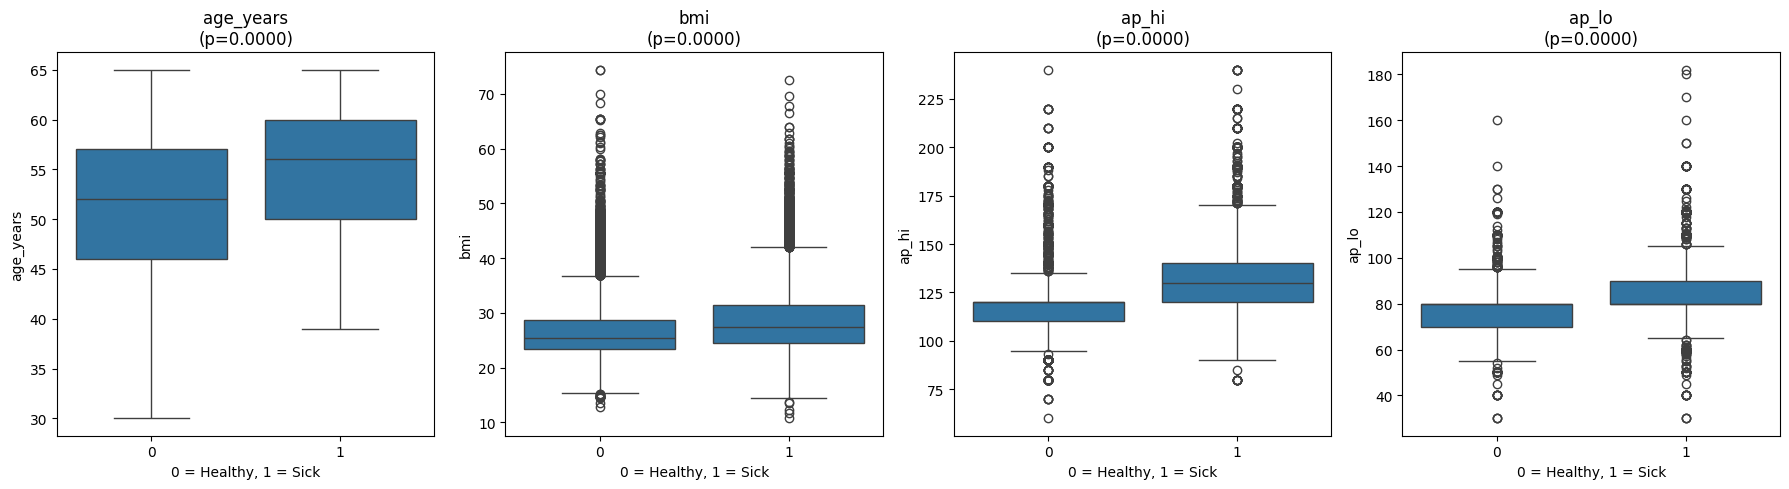

In [25]:
# T-test
conti_cols = ['age_years', 'bmi', 'ap_hi', 'ap_lo']

fig, axes = plt.subplots(1, len(conti_cols), figsize=(18, 5))

for i, col in enumerate(conti_cols):
  group0 = cardiac_clean[cardiac_clean['cardio'] == 0][col]
  group1 = cardiac_clean[cardiac_clean['cardio'] == 1][col]
  t_stat, p_val = ttest_ind(group0, group1)

  print(f"--- {col} ---")
  print(f"Mean (Healthy): {group0.mean():.2f}")
  print(f"Mean (Sick):    {group1.mean():.2f}")
  print(f"P-value:        {p_val:.6f}\n")

  sns.boxplot(x='cardio', y=col, data=cardiac_clean, ax=axes[i])
  axes[i].set_title(f'{col}\n(p={p_val:.4f})')
  axes[i].set_xlabel('0 = Healthy, 1 = Sick')

plt.tight_layout()
plt.show()

Apparently, the averages of sick group and healthy group for each feature are all significantly different. We also see that people who have cardio disease have higher values for all the features.

So having more age, higher bmi, and higher blood pressure probably increase the risk of getting disease.

Check for class imbalance

Before building a baseline model, I want to know if the dataset is balanced.

If 90% of people are healthy and only 10% are sick, a model can get 90% accuracy just by guessing healthy every time.

So we will count how many people have the disease in this dataset and if the proportion is close to 50/50, we can say that the accuracy score is reliable.

In [26]:
# Check the balance of the target variable: Close to 50/50 -> accuracy is reliable here
print("Cardiac target balance:")
print((cardiac_clean['cardio'].value_counts(normalize=True) * 100).round(2))

Cardiac target balance:
cardio
0    50.53
1    49.47
Name: proportion, dtype: float64


The baseline model will allow us to see how well we can predict cardio disease based on our dataset.

We will use the Logistic Regression. It’s basically a math equation that calculates the probability of "1" based on the columns.

How to Read the Results:
- Accuracy: The percentage of total guesses that were correct.
- Precision: When the model says "This person has heart disease", how often is it right?
- Recall: Out of all people who actually have heart disease, how many did the model find?

In [27]:
# Baseline logistic regression (only with some features)

# 1. Prepare the data (X = features, y = target)

features_simple = ['age_years', 'bmi', 'ap_hi', 'cholesterol']
X = cardiac_clean[features_simple]
y = cardiac_clean['cardio']

# 2. Split into Training (80%) and Testing (20%)
# This ensures we test the model on data it hasn't seen before - what train_test_split() does.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# It takes 70,000 rows and puts random 80% in "X_train" and 20% in "the "X_test" (that's going to be examined).
# It stores whether the 80% actually have the disease in "y_train".
# It stores whether the 20% estimated actually have the disease in "y_test".

# 3. Scaling
# Since we have a wide range of values between features (e.g. chol is either 1, 2 or 3 while blood pressure can be over 200),
# the model can think that blood pressure is 200 times more important than chol level, which is not.
# So we need to center the data (making the mean 0) and scale it (making the standard deviation 1).

scaler_simple = StandardScaler()
X_train_s = scaler_simple.fit_transform(X_train)
# Fit: It calculates the mean and standard deviation for every single one of your columns in X_train
# Transform: It then calculates the Z-score of every data point
# So X_train_s now contains the Z-scores.
X_test_s = scaler_simple.transform(X_test)
# No fit
# Transform: We are telling the scaler to use the mean and stdev it learned from the training data and apply them to the test data (X_test)
# So we ensure the test set remains unseen.

# 4. Create and train the baseline model

baseline = LogisticRegression(max_iter=1000)
# LogisticRegression(): It calculates a probability score and if it's >0.5, it predicts "Cardio" -> it gives classification (0/1)
baseline.fit(X_train_s, y_train)
# model.fit(X_train, y_train): Learning phase -> it looks at the features (X_train) and the answers (y_train) until it finds the patterns
# So the Logistic Regression looks at X_train and y_train and it calculates weights.
# It will decide for example for every 10 point increase in BP, the probability of cardio goes up by 0.15.

# 5. Make Predictions

preds = baseline.predict(X_test_s)
# We now give the trained model the 20% data (X_test), but we hide the answers (y_test). The model then guesses.

# 6. Check Performance

print(f"Baseline accuracy (4 features): {accuracy_score(y_test, preds):.2%}")
print(classification_report(y_test, preds))

Baseline accuracy (4 features): 72.22%
              precision    recall  f1-score   support

           0       0.70      0.79      0.74      6883
           1       0.76      0.65      0.70      6846

    accuracy                           0.72     13729
   macro avg       0.73      0.72      0.72     13729
weighted avg       0.73      0.72      0.72     13729



In [28]:
# Full logistic regression (with all features)

cardio_features = ['age_years', 'gender', 'height', 'weight',
                   'ap_hi', 'ap_lo', 'cholesterol', 'gluc',
                   'smoke', 'alco', 'active', 'bmi']

X_c = cardiac_clean[cardio_features]
y_c = cardiac_clean['cardio']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled  = scaler_c.transform(X_test_c)

cardio_lr = LogisticRegression(max_iter=1000)
cardio_lr.fit(X_train_c_scaled, y_train_c)

preds_lr = cardio_lr.predict(X_test_c_scaled)
print(f"Full logistic regression accuracy: {accuracy_score(y_test_c, preds_lr):.2%}")
print(classification_report(y_test_c, preds_lr))

Full logistic regression accuracy: 72.38%
              precision    recall  f1-score   support

           0       0.70      0.79      0.74      6883
           1       0.76      0.66      0.70      6846

    accuracy                           0.72     13729
   macro avg       0.73      0.72      0.72     13729
weighted avg       0.73      0.72      0.72     13729



Random forest

A Random forest is an "ensemble" model. Instead of one single logic path (like logistic regression), it creates 100 different decision trees that all vote on the result.

It is much better at catching complex interactions (like "If age > 60 AND cholesterol is low, the risk is still high").

Random forest accuracy (cardiac): 73.05%


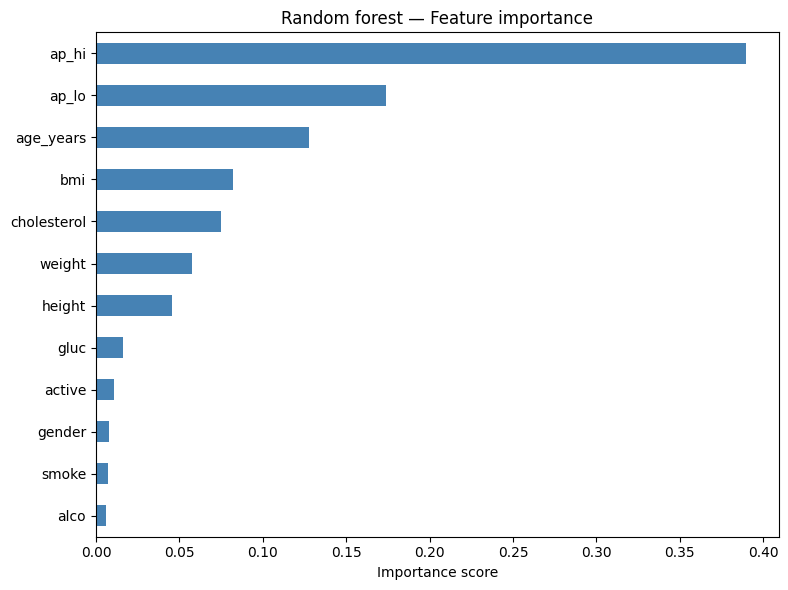

In [29]:
rf_cardio = RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', random_state=42)
# "class_weight=balanced": It tells the model that missing a sick person is just as important as missing a healthy person.
#                            Without this, a model can cheat to get high accuracy by just guessing healthy for everyone.
# n_estimators=100 means 100 trees will "vote" on each patient
rf_cardio.fit(X_train_c_scaled, y_train_c)

rf_acc = rf_cardio.score(X_test_c_scaled, y_test_c)
print(f"Random forest accuracy (cardiac): {rf_acc:.2%}")

# Feature importance
importance_series_c = pd.Series(rf_cardio.feature_importances_, index=cardio_features).sort_values(ascending=True)

importance_series_c.plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title("Random forest — Feature importance")
plt.xlabel("Importance score")
plt.tight_layout()
plt.show()

We see that ap_hi have the highest score (almost 0.4 which is two times higher than the score of other features), followed by ap_lo, age, bmi, and cholesterol. These features are all expected from the clinical aspect and also from the correlation heatmap.

Here, we move beyond the linear assumptions of logistic regression. By implementing a Random forest classifier, we capture non-linear interactions between risk factors (like the combined effect of high BMI and high Blood Pressure), which improves the predictive power.

GridSearchCV

To choose what setting to choose for our model, we will use GridSearchCV, which takes a list of options we provide, tries every single possible combination, and tells which one worked best using Cross-Validation.

In [30]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search_c = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid, cv=3, scoring='accuracy', verbose=1
)
grid_search_c.fit(X_train_c_scaled, y_train_c)

print(f"Best params:   {grid_search_c.best_params_}")
print(f"Best CV score: {grid_search_c.best_score_:.2%}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best params:   {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
Best CV score: 73.46%


XGBoost model

While Random forest builds many trees at the same time and averages them, XGBoost builds trees one after the other. Each new tree is specifically designed to fix the mistakes made by the previous trees.

In [31]:
xgb_cardio = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
xgb_cardio.fit(X_train_c_scaled, y_train_c)

print(f"XGBoost Accuracy (cardiac): {xgb_cardio.score(X_test_c_scaled, y_test_c):.2%}")

XGBoost Accuracy (cardiac): 73.25%


Combining RandomizedSearchCV and XGBoost model

In [32]:
# If GridSearchCV takes too much time - Refinement
param_dist = {
    'n_estimators'    : [100, 500, 1000],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'max_depth'       : [3, 5, 7],
    'subsample'       : [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgb_tuned = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss'),
    param_distributions=param_dist,
    n_iter=10, cv=3, verbose=1, random_state=42
)

xgb_tuned.fit(X_train_c_scaled, y_train_c)

best_xgb = xgb_tuned.best_estimator_

print(f"Best params: {xgb_tuned.best_params_}")
print(f"Best CV score: {xgb_tuned.best_score_:.2%}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'subsample': 0.6, 'n_estimators': 1000, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best CV score: 73.51%


ANN

This is a standard feed-forward neural network. By using fully connected (linear) layers, the model facilitates global feature interaction, allowing the network to learn complex, non-linear correlations between disparate input variables such as age and weight.

- Data engineering: Converting features into normalized tensors and creating shuffled mini-batches.
- Model design: Building a 64-32-2 architecture using ReLU activations.
- Training strategy: Implementing a loop that tracks both training and validation loss, using a 'patience' buffer to stop training once the model reaches its peak performance on unseen data.

Training Cardio ANN...
Epoch   5 | Train: 0.5443 | Val: 0.5528
Epoch  10 | Train: 0.5415 | Val: 0.5504
Epoch  15 | Train: 0.5399 | Val: 0.5518
Early stopping at epoch 16


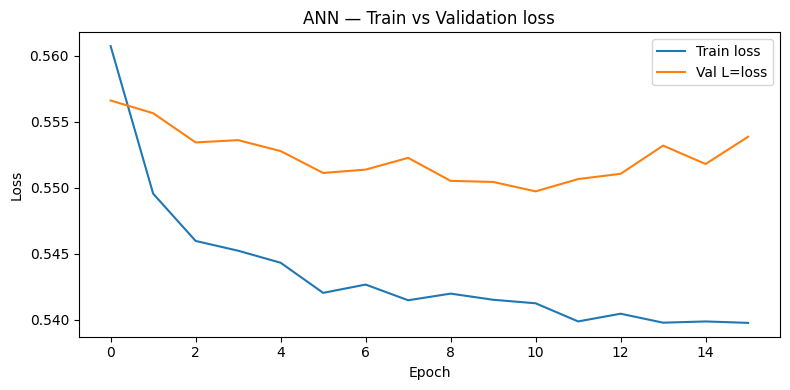

ANN Accuracy (cardiac): 73.31%


In [33]:
# Used generative AI tool for this code

# Convert to tensors
# Before PyTorch can process the data, it has to be converted from NumPy/Pandas into Tensors (multi-dimensional matrices).
X_train_t = torch.FloatTensor(X_train_c_scaled)
y_train_t = torch.LongTensor(y_train_c.values)
X_test_t  = torch.FloatTensor(X_test_c_scaled)
y_test_t  = torch.LongTensor(y_test_c.values)
# torch.Float/LongTensor: Converts features to decimals (floats) and labels to integers (longs)

# Proper shuffled validation split
X_tr_t, X_val_t, y_tr_t, y_val_t = train_test_split(
    X_train_t, y_train_t, test_size=0.1, random_state=42
)

train_loader_c = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)
# DataLoader: "data manager" -> instead of adding all the rows into the model at once, it breaks the data into batches of 64
# "shuffle=True": This ensures the model doesn't memorize the order of the data

class CardioANN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(), # ReLU: An activation function that allows the model to learn non-linear relationships
            nn.Dropout(0.2), # Randomly turns off 20% of the neurons during training -> model will not rely too heavily on any single feature.
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )
    def forward(self, x):
        return self.net(x)

model_ann = CardioANN(input_size=len(cardio_features)).to(device)
criterion = nn.CrossEntropyLoss() # Measures the distance between the model's guess and the actual label.
optimizer = optim.Adam(model_ann.parameters(), lr=0.001) # Automatically adjusts the learning rate.

# track train/val loss + early stopping
train_losses, val_losses = [], []
best_val_loss, patience_counter = float('inf'), 0
patience, best_state = 5, None

print("Training Cardio ANN...")
for epoch in range(50):
    model_ann.train()
    batch_losses = []
    for inputs, labels in train_loader_c:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad() # Clears the memory of the previous guess so the model can learn fresh from the current batch.
        loss = criterion(model_ann(inputs), labels)
        loss.backward() # The model calculates how much each weight was responsible for the error.
        optimizer.step() # The model actually updates its internal weights to be slightly more accurate next time.
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    model_ann.eval() # Switches the model to testing mode (turns off Dropout so we get a consistent measurement).
    with torch.no_grad():
        val_loss = criterion(
            model_ann(X_val_t.to(device)),
            y_val_t.to(device)
        ).item()
    val_losses.append(val_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d} | Train: {train_losses[-1]:.4f} | Val: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {k: v.clone() for k, v in model_ann.state_dict().items()}
    else: # If the Validation Loss stops improving for 5 epochs (patience), the code terminates the training.
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

model_ann.load_state_dict(best_state)
# It restores the model to the version that had the best validation score, rather than keeping the overfitted version from the final epoch.

# Plot training curves
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Val L=loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ANN — Train vs Validation loss')
plt.legend()
plt.tight_layout()
plt.show()

# Evaluate
model_ann.eval()
with torch.no_grad():
    _, predicted = torch.max(model_ann(X_test_t.to(device)), 1)
    ann_acc = (predicted == y_test_t.to(device)).float().mean().item()
print(f"ANN Accuracy (cardiac): {ann_acc:.2%}")

For the cardiac data, we experimented with three distinct architectures: Random Forest, XGBoost, and a ANN.

We see that the dataset reaches a performance ceiling at ~73%, suggesting that further improvements would require external data or complex feature engineering rather than more advanced model architectures.

In [34]:
heart.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [35]:
# See if there are missing values
print("--- heart missing values ---")
print(heart.isnull().sum())

--- heart missing values ---
Age                  0
RestingBP            0
Cholesterol          0
FastingBS            0
MaxHR                0
Oldpeak              0
HeartDisease         0
Sex_M                0
ChestPainType_ATA    0
ChestPainType_NAP    0
ChestPainType_TA     0
RestingECG_Normal    0
RestingECG_ST        0
ExerciseAngina_Y     0
ST_Slope_Flat        0
ST_Slope_Up          0
dtype: int64


In [36]:
heart.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


For heart dataset, based on common medical datasets:

- RestingBP	(Resting Blood Pressure) upon admission to the hospital
- Cholesterol: Actualy cholesterol concentration in serum
- FastingBS (Fasting Blood Sugar): Amount of sugar in blood after a person hasn't eaten (0 = Normal, 1 = High - a risk factor for diabetes and heart disease)
- MaxHR (Maximum Heart Rate) achieved during a stress test (higher usually means younger)
- Oldpeak: Measurement taken during a stress test (like running) to measure the difference between the ST segment in ECG wave at rest and the same part when the heart is under stress. (0 = Normal, Higher numbers = More severe ST depression - the heart is struggling to get enough oxygen during exercise)
- ChestPainType	ATA/NAP/TA: Different types of chest pain. ATA (Atypical) and NAP (Non-Anginal) are often less likely to be a heart attack than TA( Typical Angina)
- RestingECG: Heart Rhythm - is the electrical pattern normal at rest, or are there ST wave abnormalities?
- ExerciseAngina_Y:	Pain during Workout - does the patient get chest pain specifically when they start moving/exercising?
- ST_Slope: Recovery - when the heart stops exercising, how does the electrical signal return to normal? Up is usually healthy, flat or Down is a warning sign.
- Heart Disease (Target): 1 = Disease, 0 = No Disease

Cleaning heart dataset

We will filter to create a new dataframe (heart_clean) that only keeps values that biologically make sense.

In medical terms:
- Age must be realistic (less than 120).
- RestingBP should be between 50 and 250.
- Cholesterol cannot be 0 (between 50 and 650).
- MaxHR should be between 40 and 230.
- Oldpeak is generally between -3 and 10.

In [37]:
heart_clean = heart[
    (heart['Age'] > 0) & (heart['Age'] < 150) &
    (heart['RestingBP'] > 50) & (heart['RestingBP'] < 250) &
    (heart['Cholesterol'] > 50) & (heart['Cholesterol'] < 650) &
    (heart['MaxHR'] > 40) & (heart['MaxHR'] < 230) &
    (heart['Oldpeak'] > -3) & (heart['Oldpeak'] < 10)
].copy()

print(f"Original shape: {heart.shape}")
print(f"Cleaned shape:  {heart_clean.shape}")

# Check the balance of the target variable: Close to 50/50 -> accuracy is reliable here
print(f"\nTarget balance:")
print((heart_clean['HeartDisease'].value_counts(normalize=True) * 100).round(2))

Original shape: (918, 16)
Cleaned shape:  (746, 16)

Target balance:
HeartDisease
0    52.28
1    47.72
Name: proportion, dtype: float64


In [38]:
heart_clean.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000
mean,52.882038,133.022788,244.635389,0.167560,140.226542,0.901609,0.477212
std,9.505888,17.282750,59.153524,0.373726,24.524107,1.072861,0.499816
min,28.000000,92.000000,85.000000,0.000000,69.000000,-0.100000,0.000000
25%,46.000000,120.000000,207.250000,0.000000,122.000000,0.000000,0.000000
50%,54.000000,130.000000,237.000000,0.000000,140.000000,0.500000,0.000000
75%,59.000000,140.000000,275.000000,0.000000,160.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


EDA of heart dataset

HeartDisease
0    50.171795
1    55.851124
Name: Age, dtype: float64


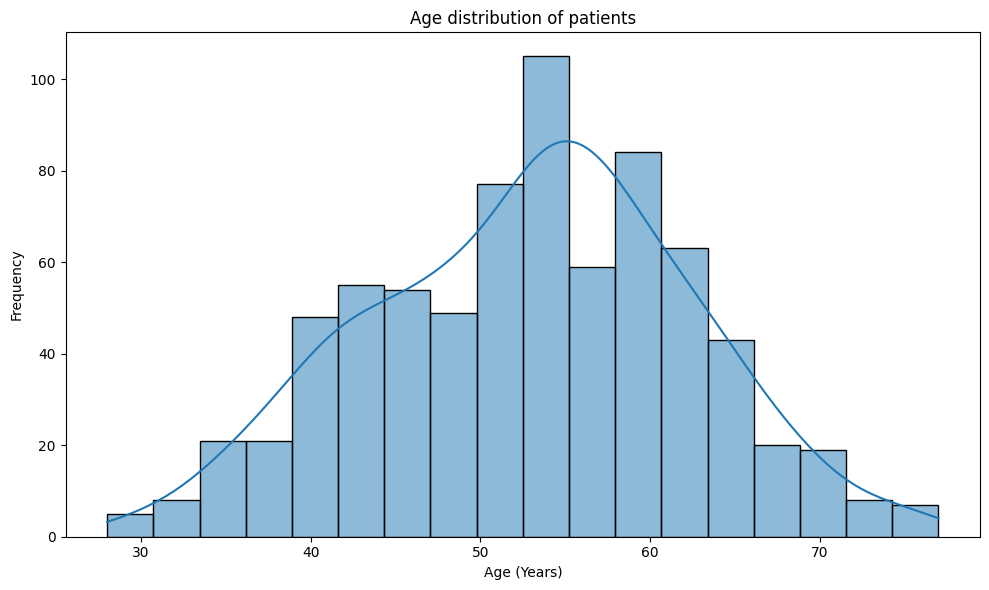

In [39]:
# Average age of sick vs healthy
print(heart_clean.groupby('HeartDisease')['Age'].mean())

plt.figure(figsize=(10, 6))
sns.histplot(heart_clean['Age'], kde=True)
plt.title("Age distribution of patients")
plt.xlabel("Age (Years)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

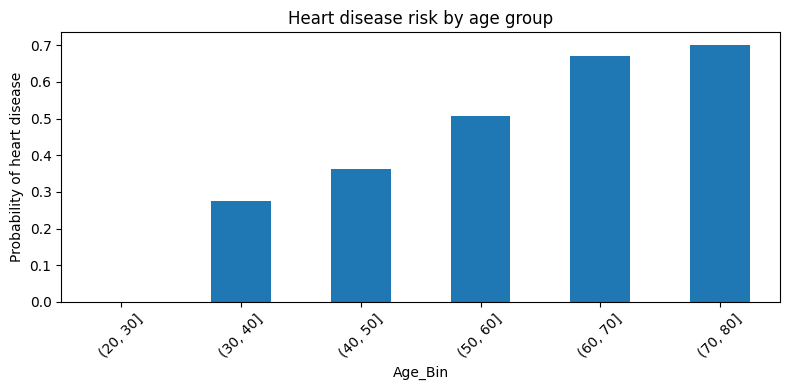

In [40]:
# Age bins
heart_clean['Age_Bin'] = pd.cut(heart_clean['Age'], bins=[20, 30, 40, 50, 60, 70, 80])

# Calculate % of heart disease for each age group
age_risk = heart_clean.groupby('Age_Bin', observed=False)['HeartDisease'].mean()

age_risk.plot(kind='bar', figsize=(8, 4))
plt.ylabel("Probability of heart disease")
plt.title("Heart disease risk by age group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Here, we see the increasing probabilities of getting disease as the age increases (about 0.35 for patients less than 50s and about 0.7 for patients over 60s).

The jump from 0.35 to 0.7 confirms that age is a major risk "multiplier" in this dataset.

In [41]:
heart_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 746 entries, 0 to 917
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Age                746 non-null    int64   
 1   RestingBP          746 non-null    int64   
 2   Cholesterol        746 non-null    int64   
 3   FastingBS          746 non-null    int64   
 4   MaxHR              746 non-null    int64   
 5   Oldpeak            746 non-null    float64 
 6   HeartDisease       746 non-null    int64   
 7   Sex_M              746 non-null    bool    
 8   ChestPainType_ATA  746 non-null    bool    
 9   ChestPainType_NAP  746 non-null    bool    
 10  ChestPainType_TA   746 non-null    bool    
 11  RestingECG_Normal  746 non-null    bool    
 12  RestingECG_ST      746 non-null    bool    
 13  ExerciseAngina_Y   746 non-null    bool    
 14  ST_Slope_Flat      746 non-null    bool    
 15  ST_Slope_Up        746 non-null    bool    
 16  Age_Bin      

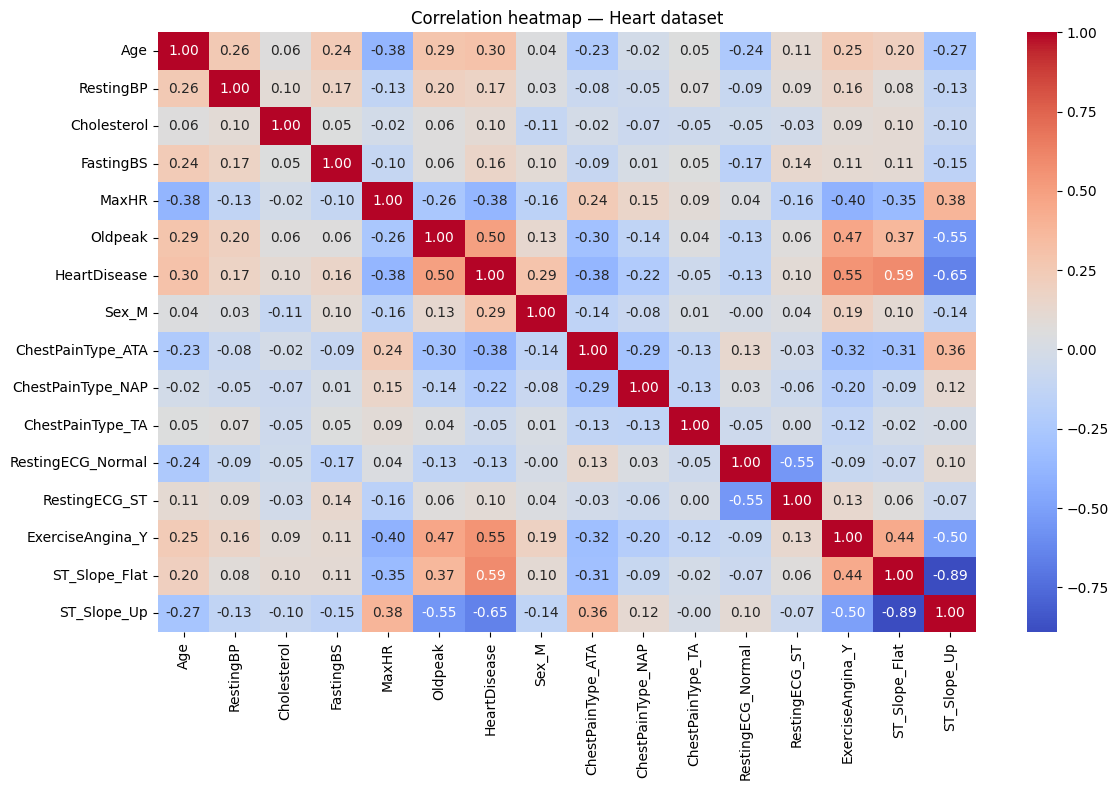

In [42]:
# Correlation heatmap
numeric_and_bool = heart_clean.select_dtypes(include=['number', 'bool']) # to exclude the age bins

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_and_bool.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation heatmap — Heart dataset")
plt.tight_layout()
plt.show()

According to the correlation heatmap, there are several features having a correlation magnitude bigger than 0.5

- ST_Slope_Up (-0.6 approx): We have a negative correlation here, which makes sense as "Up" is the healthy way for a heart to recover.
- ST_Slope_Flat (0.59): We have a positive correlation and it's normal as if the heart's electrical signal stays flat after exercise, it strongly suggests problems with blood circulation.
- Oldpeak (0.50): A positive correlation as if the heart struggles to get enough oxygen during exercise, there's highly a problem with heart.
- ExerciseAngina_Y (0.55): A positive correlation as if someone gets chest pain while walking/running, they almost certainly have a heart issue.

So the correlation analysis confirms clinical expectations: electrical abnormalities during exercise (Oldpeak and ST_Slope_Flat) and physical symptoms (ExerciseAngina_Y) are the strongest predictors of disease.

Statistical tests

- T-Test (for continuous features): We want to see if the sick group has a significantly different average than the healthy group for these features.
- Chi-Square Test (for category features): We want to see if the distribution of disease is different across the categories.

--- Age ---
Mean (Healthy): 50.17
Mean (Sick):    55.85
P-value:        0.0000 - Significant

--- RestingBP ---
Mean (Healthy): 130.16
Mean (Sick):    136.15
P-value:        0.0000 - Significant

--- Cholesterol ---
Mean (Healthy): 238.77
Mean (Sick):    251.06
P-value:        0.0045 - Significant

--- MaxHR ---
Mean (Healthy): 149.06
Mean (Sick):    130.55
P-value:        0.0000 - Significant

--- Oldpeak ---
Mean (Healthy): 0.39
Mean (Sick):    1.46
P-value:        0.0000 - Significant



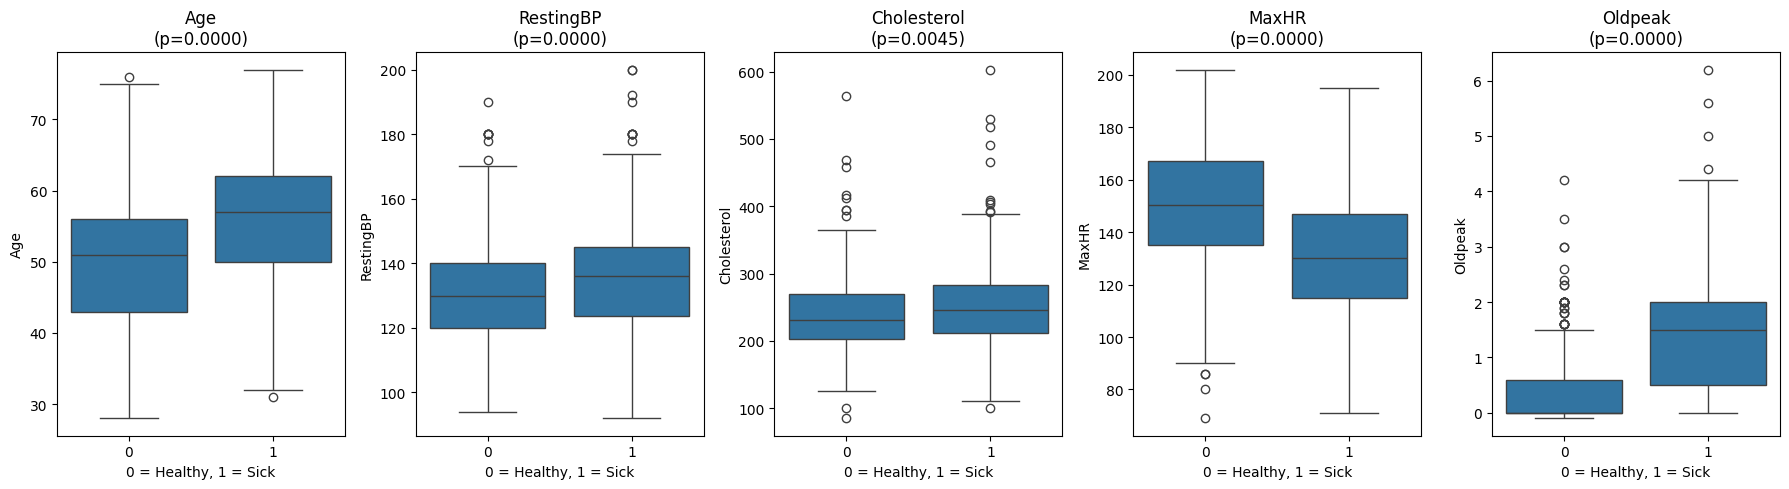

In [43]:
# T-test
conti_feat = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(1, len(conti_feat), figsize=(18, 5))

for i, col in enumerate(conti_feat):
  group0 = heart_clean[heart_clean['HeartDisease'] == 0][col]
  group1 = heart_clean[heart_clean['HeartDisease'] == 1][col]
  t_stat, p_val = ttest_ind(group0, group1)
  status = "Significant" if p_val < 0.05 else "Not Significant"

  print(f"--- {col} ---")
  print(f"Mean (Healthy): {group0.mean():.2f}")
  print(f"Mean (Sick):    {group1.mean():.2f}")
  print(f"P-value:        {p_val:.4f} - {status}\n")

  sns.boxplot(x='HeartDisease', y=col, data=heart_clean, ax=axes[i])
  axes[i].set_title(f'{col}\n(p={p_val:.4f})')
  axes[i].set_xlabel('0 = Healthy, 1 = Sick')

plt.tight_layout()
plt.show()

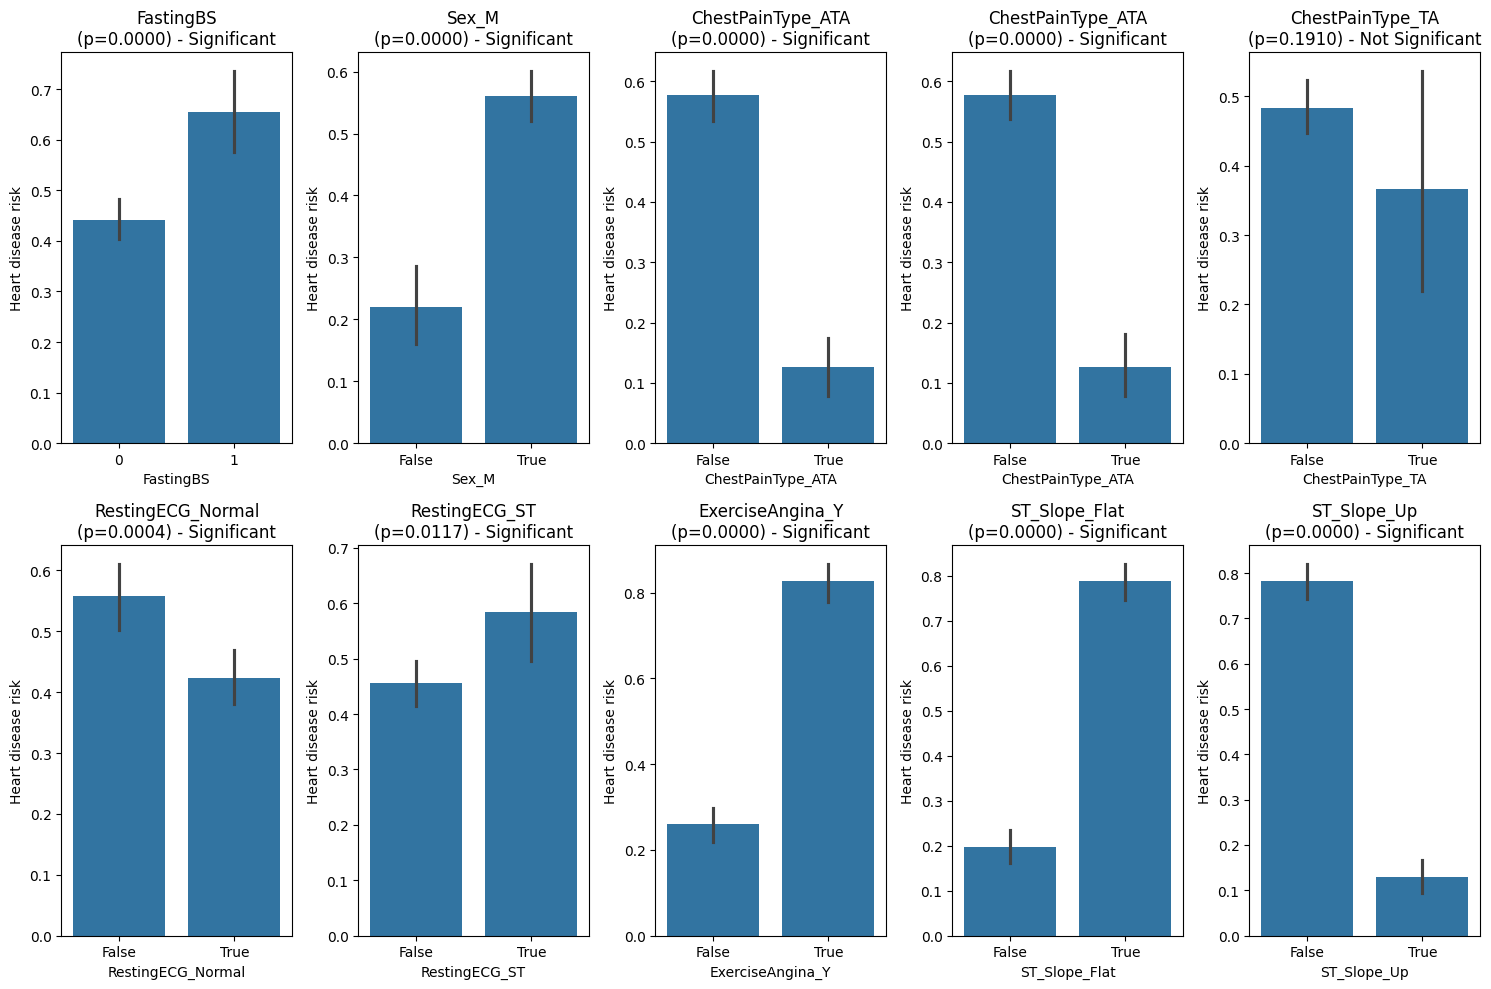

In [44]:
# Chi-square test
cat_feat = ['FastingBS', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_ATA', 'ChestPainType_TA',
            'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']

plt.figure(figsize=(15, 10))

for i, col in enumerate(cat_feat):
  plt.subplot(2, 5, i+1)
  sns.barplot(x=col, y='HeartDisease', data=heart_clean)

  contingency = pd.crosstab(heart_clean[col], heart_clean['HeartDisease'])
  chi2, p, dof, _ = chi2_contingency(contingency)
  status = "Significant" if p < 0.05 else "Not Significant"
  plt.title(f"{col}\n(p={p:.4f}) - {status}")
  plt.ylabel("Heart disease risk")

plt.tight_layout()
plt.show()

We see that all these categorial features except ChestPainType_TA have significant relationship with the risk of having heart disease.

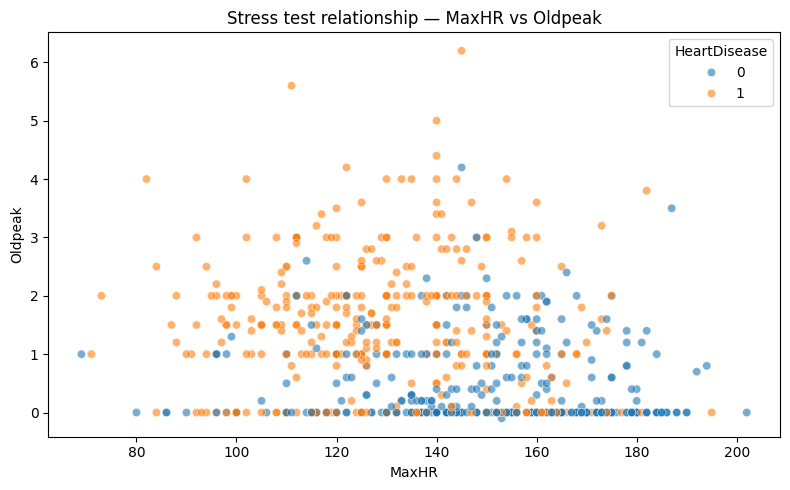

In [45]:
# Scatter: MaxHR vs Oldpeak
plt.figure(figsize=(8, 5))
sns.scatterplot(x='MaxHR', y='Oldpeak', hue='HeartDisease', data=heart_clean, alpha=0.6)
plt.title("Stress test relationship — MaxHR vs Oldpeak")
plt.tight_layout()
plt.show()

We see that many 1s (sick group) are at the left (so lower maxHR) and top (so higher oldpeak) which is expected.

            mean  count
Female  0.219780    182
Male    0.560284    564
Risk gap (Male vs Female): 34.05%


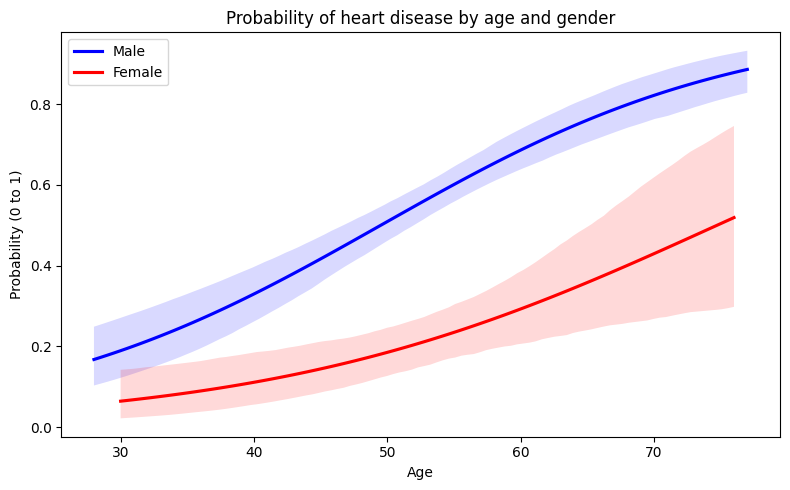

In [46]:
# Gender analysis

# Group by Gender and calculate the mean of HeartDisease (which is the probability)
gender_impact = heart_clean.groupby('Sex_M')['HeartDisease'].agg(['mean', 'count'])
gender_impact.index = ['Female', 'Male']
print(gender_impact)

males = heart_clean[heart_clean['Sex_M'] == 1]
females = heart_clean[heart_clean['Sex_M'] == 0]
print(f"Risk gap (Male vs Female): {males['HeartDisease'].mean() - females['HeartDisease'].mean():.2%}")

plt.figure(figsize=(8, 5))
sns.regplot(x='Age', y='HeartDisease', data=males,
            scatter=False, label='Male', color='blue', logistic=True)
sns.regplot(x='Age', y='HeartDisease', data=females,
            scatter=False, label='Female', color='red', logistic=True)
plt.title("Probability of heart disease by age and gender")
plt.ylabel("Probability (0 to 1)")
plt.legend()
plt.tight_layout()
plt.show()

In this dataset, males have a much higher percentage of getting disease than females. So being male is as big a risk factor here. But this doesn't necessarily mean that it's the general case in reality as well as we don't know what sample this study has taken.

Also we see that females have increasing probabiliy of getting disease as they get older. Males just have higher probability throughout the age than females in general.

Now we will build again the baseline model using logistic regression that will allow us to see how well we can predict heart disease based on this dataset.

In [47]:
# Baseline logistic regression (with all features)
heart_features = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
                  'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
                  'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y',
                  'ST_Slope_Flat', 'ST_Slope_Up']

X_h = heart_clean[heart_features]
y_h = heart_clean['HeartDisease']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_h, y_h, test_size=0.2, random_state=42)

scaler_h = StandardScaler()
X_train_h_scaled = scaler_h.fit_transform(X_train_h)
X_test_h_scaled  = scaler_h.transform(X_test_h)

heart_lr = LogisticRegression(max_iter=1000)
heart_lr.fit(X_train_h_scaled, y_train_h)

preds_h = heart_lr.predict(X_test_h_scaled)
print(f"Heart baseline accuracy: {accuracy_score(y_test_h, preds_h):.2%}")
print(classification_report(y_test_h, preds_h))

Heart baseline accuracy: 89.33%
              precision    recall  f1-score   support

           0       0.86      0.93      0.89        71
           1       0.93      0.86      0.89        79

    accuracy                           0.89       150
   macro avg       0.89      0.90      0.89       150
weighted avg       0.90      0.89      0.89       150



As from the accuracy, this is a better model than with the first dataset.

In the first one, we only had basic measurements like height, weight, and BP.

In this dataset, we have:
- The stress test (Oldpeak, MaxHR): This tells us how the heart actually performs under pressure.
- The electrical signal (ST_Slope): This is a direct indicater of the heart's health.

Random forest accuracy (heart): 90.67%


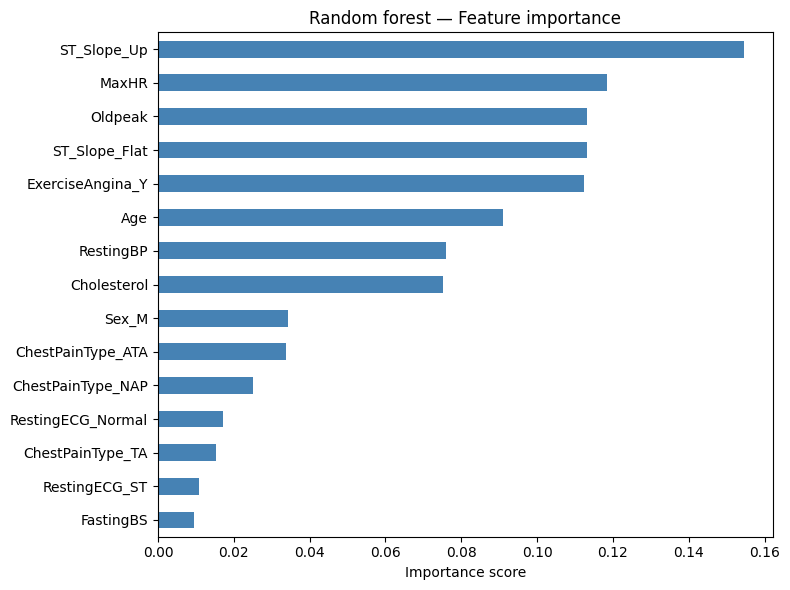

In [48]:
# Random forest
rf_heart = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_heart.fit(X_train_h_scaled, y_train_h)

print(f"Random forest accuracy (heart): {rf_heart.score(X_test_h_scaled, y_test_h):.2%}")

# Feature importance
importance_series_h = pd.Series(rf_heart.feature_importances_, index=heart_features).sort_values(ascending=True)

importance_series_h.plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title("Random forest — Feature importance")
plt.xlabel("Importance score")
plt.tight_layout()
plt.show()

We see that ST_Slope_Up has the highest importnance score, reaching up to almost 0.16. But this score doesn't have much difference with the score of other features. Especially, MaxHR, Oldpeak, ST_Slop_Flat, and ExerciseAngina_Y all have same score of 0.12. This suggests that this model takes almost all the feautres as being equivalently important for its prediction, which might explain the high accuracy of the model.

In [49]:
# XGBoost
xgb_heart = XGBClassifier(
    n_estimators=100, max_depth=4,
    learning_rate=0.1, random_state=42
)
xgb_heart.fit(X_train_h_scaled, y_train_h)

print(f"XGBoost accuracy (heart): {xgb_heart.score(X_test_h_scaled, y_test_h):.2%}")

XGBoost accuracy (heart): 88.00%


In [50]:
# GridSearchCV
param_grid_h = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [3, 5, 7, 10],
    'criterion'   : ['gini', 'entropy']
}

grid_h = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_h, cv=5, verbose=1
)
grid_h.fit(X_train_h_scaled, y_train_h)

print(f"Best heart params:   {grid_h.best_params_}")
print(f"Best CV score:       {grid_h.best_score_:.2%}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best heart params:   {'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 200}
Best CV score:       86.75%


We don't do RandomizedSearchCV or ANN here because the heart dataset doesn't have much data to perform them.

We will now put the two models next to each other and compare them.

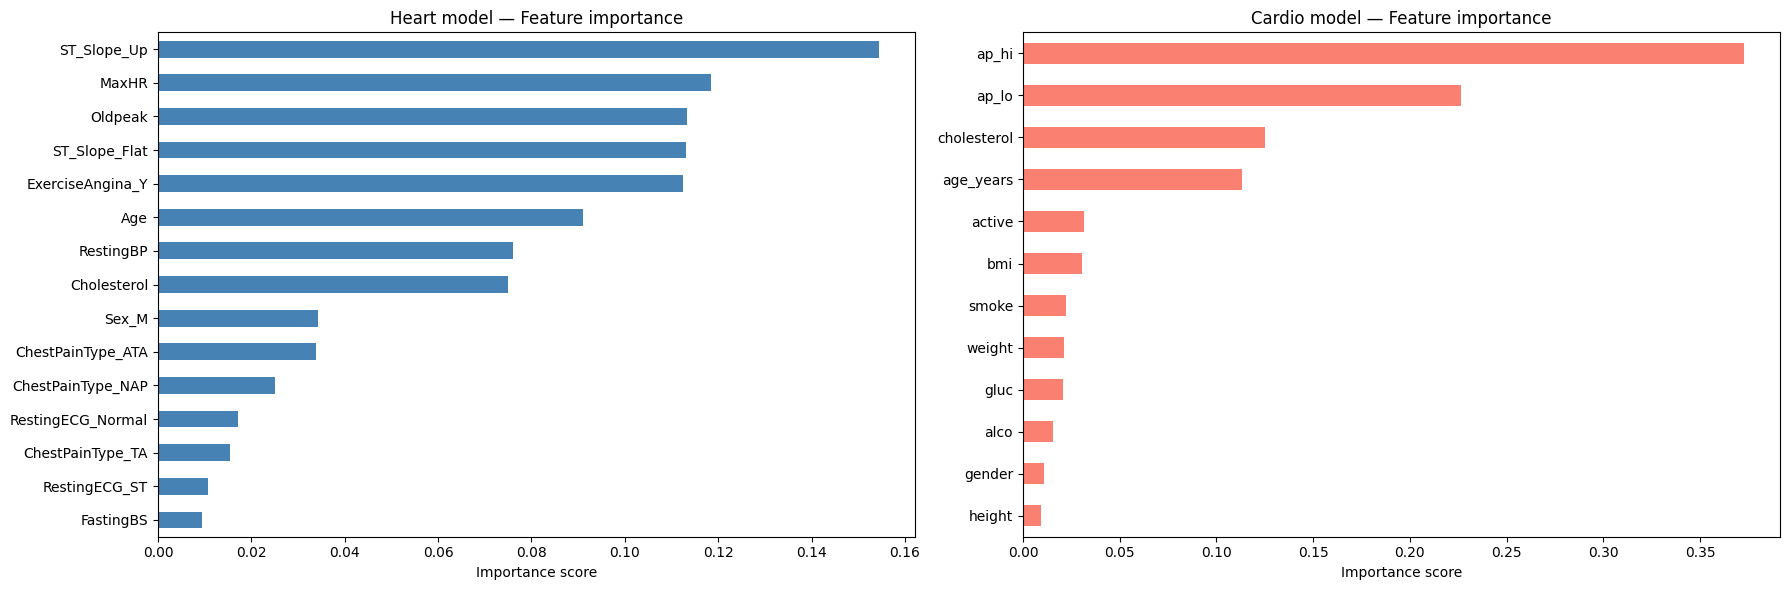

In [51]:
# Feature importance plots for both models
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heart — Random forest
pd.Series(rf_heart.feature_importances_, index=heart_features)\
  .sort_values()\
  .plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title("Heart model — Feature importance")
axes[0].set_xlabel("Importance score")

# Cardiac — best XGBoost from tuning
pd.Series(best_xgb.feature_importances_, index=cardio_features)\
  .sort_values()\
  .plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title("Cardio model — Feature importance")
axes[1].set_xlabel("Importance score")

plt.tight_layout()
plt.show()

ROC curve and AUC score

While accuracy tells us how often the model is correct at a standard 50% threshold, the ROC-AUC shows us the model's overall 'intelligence'. It shows how our model performs at every possible threshold.

It helps us decide where to set the alarm: do we want to be extra cautious to catch every sick patient, or do we want to avoid bothering healthy people with false alarms?

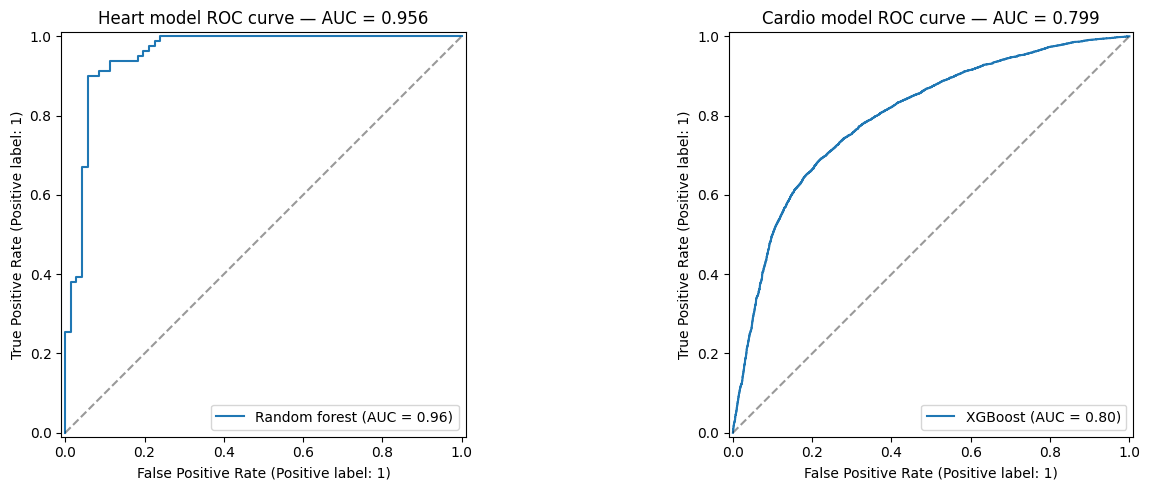

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_estimator(rf_heart, X_test_h_scaled, y_test_h, ax=axes[0], name='Random forest')
auc_h = roc_auc_score(y_test_h, rf_heart.predict_proba(X_test_h_scaled)[:, 1])
axes[0].set_title(f"Heart model ROC curve — AUC = {auc_h:.3f}")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)

RocCurveDisplay.from_estimator(best_xgb, X_test_c_scaled, y_test_c, ax=axes[1], name='XGBoost')
auc_c = roc_auc_score(y_test_c, best_xgb.predict_proba(X_test_c_scaled)[:, 1])
axes[1].set_title(f"Cardio model ROC curve — AUC = {auc_c:.3f}")
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)

plt.tight_layout()
plt.show()

For heart model:
- We see that the blue line shoots almost straight up to the top-left corner before flattening out. It reaches the true positive rate (sensitivity) of nearly 0.9 while the false positive rate is still very low (under 0.1). This means that it can catch 90% of sick patients while only bothering about 10% of healthy people with a false alarm.
- The AUC of 0.956 is also good indicator of the model's prediction. It means there is a 95.6% chance that a randomly chosen sick person will have a higher risk score than a randomly chosen healthy person.

For cardio model:
- We have a smoother curve here. For this model, to catch 80% of the sick people, it has to bother 30% of healthy people. Moreover, to catch 90% of the sick people, it has to bother more than 60% of healthy people, which more than half.
- The AUC of 0.8 also indicates that this model has lower discriminative power between the sick and healthy classes than the heart model.

(The grey line is the guessing line. If the blue curve is on this line, it means that the model is almost guessing randomly.)

So the heart model outperforms the cardio model, achieving an higher AUC of 0.956. The steepness of the first curve indicates a better ability to identify the disease risk at very low false-positive thresholds, making it the more clinically viable choice between the two models.

Confusion matrices

To see if the model is "cheating" (the model might just be guessing "healthy" for everyone), we will produce a confusion matrix — a 2x2 table that shows exactly where the model succeeded and where it failed guessing.

How to read the result:
- Top-Left: Number of healthy people correctly identified (Good).
- Bottom-Right: Number of sick people correctly identified (Good).
- Bottom-Left (false negative) : Number sick people the model guessed healthy.
- Top-Right (false positive): Number of healthy people the model guessed sick.

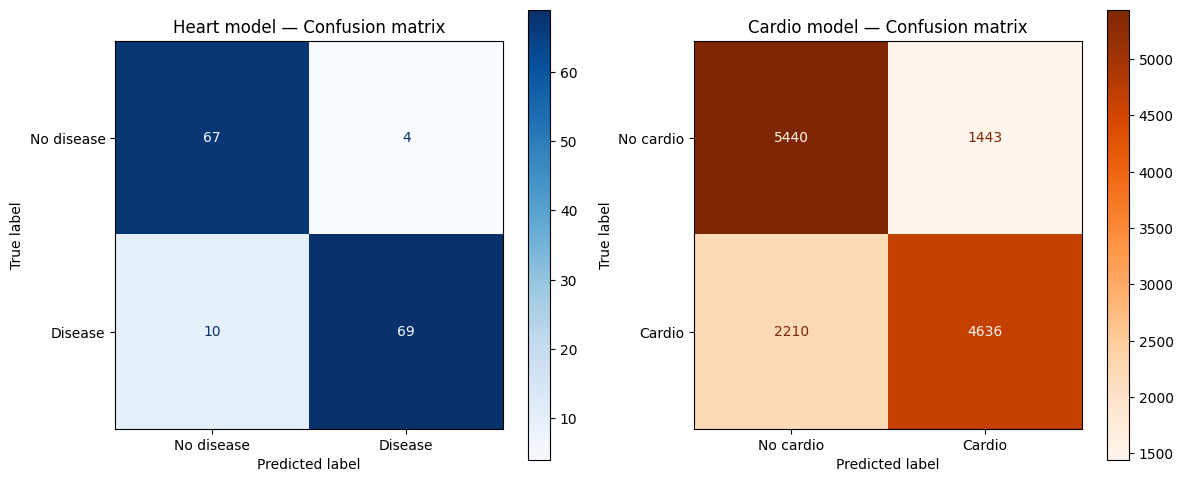

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(
    rf_heart, X_test_h_scaled, y_test_h,
    display_labels=['No disease', 'Disease'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title("Heart model — Confusion matrix")

ConfusionMatrixDisplay.from_estimator(
    best_xgb, X_test_c_scaled, y_test_c,
    display_labels=['No cardio', 'Cardio'],
    cmap='Oranges', ax=axes[1]
)
axes[1].set_title("Cardio model — Confusion matrix")

plt.tight_layout()
plt.show()

Despite the high AUC scores, both models exhibit a significant number of false negatives, which reveals a critical gap in class separability. While the models can rank patients by risk (as shown by the AUC), the high error rate at the chosen threshold suggests that the current features may overlap too heavily between classes. This indicates that the input variables may lack the specific biomarkers or predictive signals necessary to definitively isolate positive cases, leading to a model that is currently too conservative for clinical reliability.

But it is also possible that the chosen threshold is too high. We can chck this with the SHAP plot.

SHAP

SHAP (SHapley Additive exPlanations) shows for each individual patient, which features pushed the prediction toward disease or away from it.

It assigns every single feature a score for every single patient. A positive SHAP value means that feature increased the predicted risk for that person. A negative SHAP value means it decreased it.

How to read the result:
- The summary plot shows all patients at once. Each row is one feature and each dot is one patient. The color tells whether that patient had a high or low value for that feature. The horizontal position tells whether it pushed the risk up or down.
- The waterfall plot (the single patient one) shows just one patient as a vertical bar and shows features each contributing to push the model from the base value (the average model output over the training dataset we passed) to the model output. Features pushing toward disease are shown in red going right, and features pushing away are in blue going left.

Computing SHAP values — Heart model...
Computing SHAP values — Cardio model...


/tmp/ipykernel_4122/4156647504.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_heart, X_test_h, feature_names=heart_features, plot_size=(10, 6), show=False)


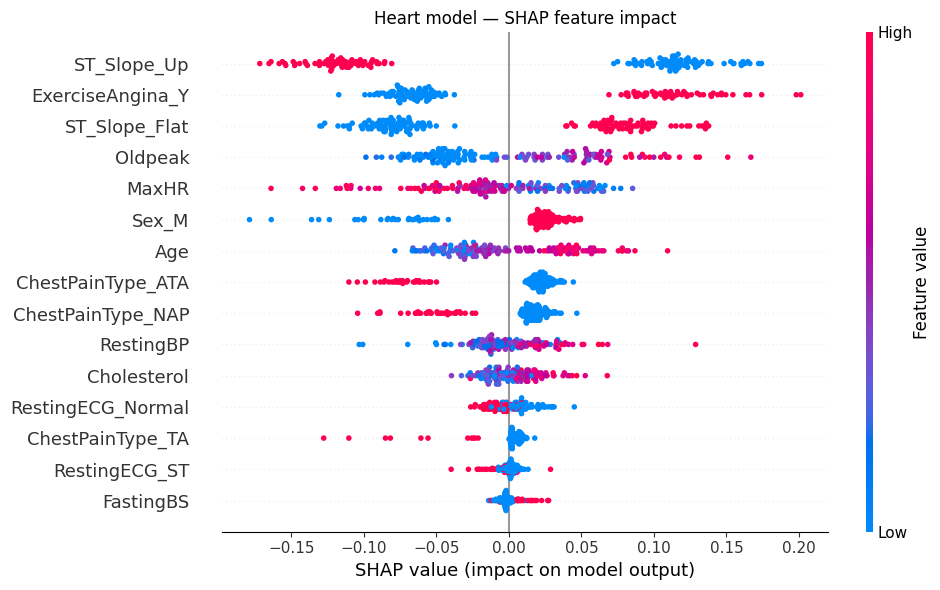

/tmp/ipykernel_4122/4156647504.py:35: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_cardio, X_test_c_scaled, feature_names=cardio_features, plot_size=(10, 5), show=False)


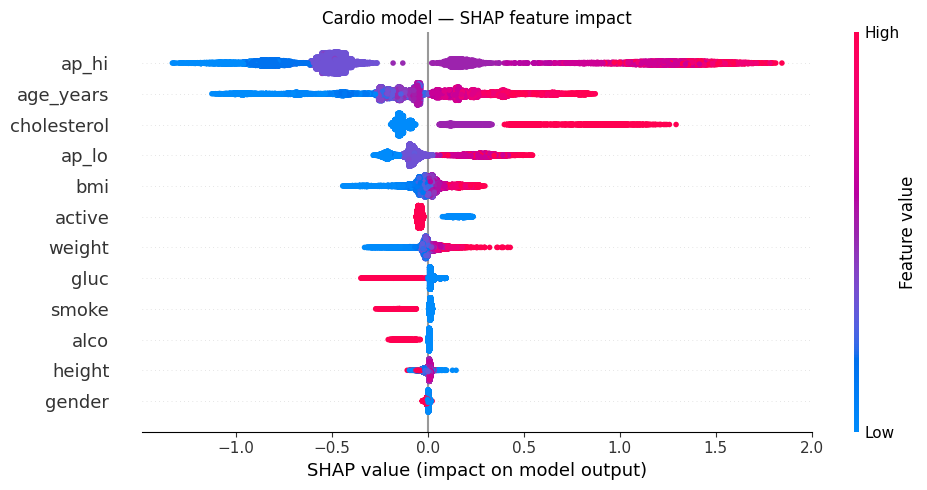

In [54]:
# Used generative AI tool for this code

# Step 1: Compute SHAP values

print("Computing SHAP values — Heart model...")
explainer_h = shap.TreeExplainer(rf_heart)
shap_values_h = explainer_h.shap_values(X_test_h_scaled)

# handle old format (list) vs new format (3D array)
if isinstance(shap_values_h, list):
  sv_heart = shap_values_h[1]
else:
  sv_heart = shap_values_h[:, :, 1]

print("Computing SHAP values — Cardio model...")
explainer_c = shap.TreeExplainer(best_xgb)
shap_values_c = explainer_c.shap_values(X_test_c_scaled)

# XGBoost binary returns 2D directly
if isinstance(shap_values_c, list):
  sv_cardio = shap_values_c[1]
else:
  sv_cardio = shap_values_c

# Step 2: Summary plots

# Heart
shap.summary_plot(sv_heart, X_test_h, feature_names=heart_features, plot_size=(10, 6), show=False)
plt.title("Heart model — SHAP feature impact")
plt.tight_layout()
plt.show()
plt.close('all')

# Cardio
shap.summary_plot(sv_cardio, X_test_c_scaled, feature_names=cardio_features, plot_size=(10, 5), show=False)
plt.title("Cardio model — SHAP feature impact")
plt.tight_layout()
plt.show()
plt.close('all')

For heart model:
- We see that ST_Slope_Up has all its red dots (high value = true/1) on the left side (negative SHAP), meaning having this feature pushes risk down. It confirms that patients whose hearts recover with an upward slope are consistently predicted as healthier. Similarly, the blue dots (low value = false/0) are on the right side (positive SHAP), meaning not having up sign incrases the risk of having disease. This corresponds to our biological knowledge so our model validate the clinical aspect automatically.
- On the contrary, ST_Slope_Flat shows the reserve result, confirming our previous result again.
- Most of other boolean features also show distinct separation between true and false values. Being true for ExerciseAngina_Y increases SHAP value, confirming that having chest pain during workout contributes strongly to the risk. But there're also exceptions. For example, being true for RestingECG_ST decreases SHAP value, which is unexpected as if someone has anormalities in ST segment in their ECG graph, they are likely to have heart disease. But our model thought the opposite way. After, the SHAP value remains very small (less than 0.05) so it might not have impacted the prediction that much.
- Other continuous feautres are more widespread rather than being in clusters. Features like MaxHR (negative correlation with risk), Oldpeak, and Age (positive correlation) follow expected medical trends. Interestingly, Cholesterol showed a surprisingly low impact; this may suggest that in this specific dataset, other electrical or physical stress markers were more immediate predictors of disease than long-term lipid levels.

But overall, we can see that our heart model has learned clinical aspects automatically and can give clinical predictions thanks to its clear separation of features, which confirms the high AUC (0.956). This suggests that the high false negative rate in the confusion matrix is likely due to an overly conservative decision threshold (0.5) rather than a lack of model intelligence.

For cardio model:
- We see that having higher ap_hi (systolic blood pressure), higher age, and higher cholesterol increases the risk of having heart disease. But the model relies heavily on these features. While these are valid risk factors, we have a lack of feature depth compared to the heart model.
- Besides, we see that having higher weight has higher risk than having higher bmi, which suggests that our model is biased and can't distinguish other biological factors. It appears to view absolute weight as a risk factor without properly accounting for its ratio to height. In a perfectly balanced biological model, we would expect BMI to be the more important factor.

The features in the cardio model exhibit lower overall SHAP magnitudes and less distinct clustering. This blurriness in feature importance directly reflects the lower AUC (0.80) and the model's struggle to clearly separate healthy and sick classes.

Heart  — most confident indices : [142, 81, 31]
Heart  — most uncertain indices : [22, 8, 100]
Cardio — most confident indices : [2748, 7161, 2873]
Cardio — most uncertain indices : [5130, 3281, 9247]

>>> Heart model: most confident predictions

Heart model (Random forest) — Patient #142
Feature values:
Age                     64
RestingBP              141
Cholesterol            244
FastingBS                1
MaxHR                  116
Oldpeak                1.5
Sex_M                 True
ChestPainType_ATA    False
ChestPainType_NAP    False
ChestPainType_TA     False
RestingECG_Normal    False
RestingECG_ST         True
ExerciseAngina_Y      True
ST_Slope_Flat         True
ST_Slope_Up          False


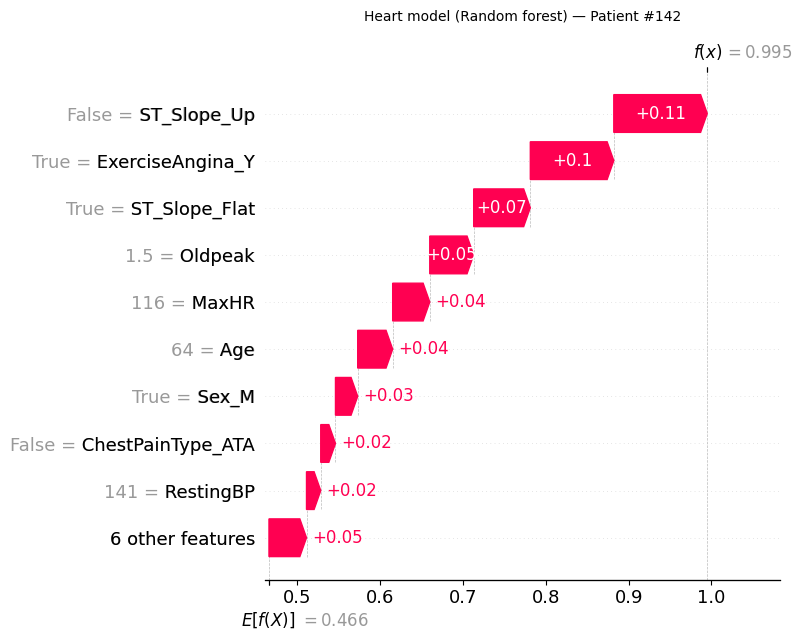


Heart model (Random forest) — Patient #81
Feature values:
Age                     64
RestingBP              143
Cholesterol            306
FastingBS                1
MaxHR                  115
Oldpeak                1.8
Sex_M                 True
ChestPainType_ATA    False
ChestPainType_NAP    False
ChestPainType_TA     False
RestingECG_Normal    False
RestingECG_ST         True
ExerciseAngina_Y      True
ST_Slope_Flat         True
ST_Slope_Up          False


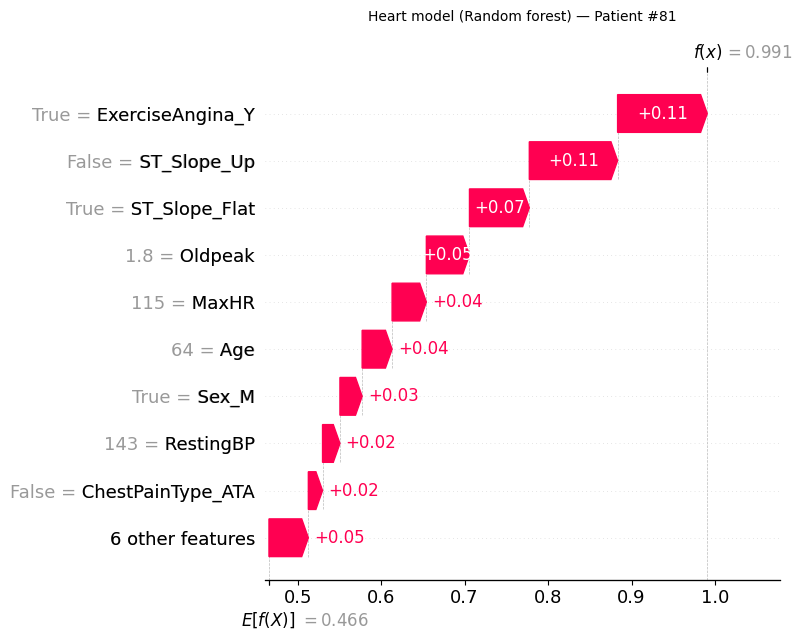


Heart model (Random forest) — Patient #31
Feature values:
Age                     67
RestingBP              140
Cholesterol            219
FastingBS                0
MaxHR                  122
Oldpeak                2.0
Sex_M                 True
ChestPainType_ATA    False
ChestPainType_NAP    False
ChestPainType_TA     False
RestingECG_Normal    False
RestingECG_ST         True
ExerciseAngina_Y      True
ST_Slope_Flat         True
ST_Slope_Up          False


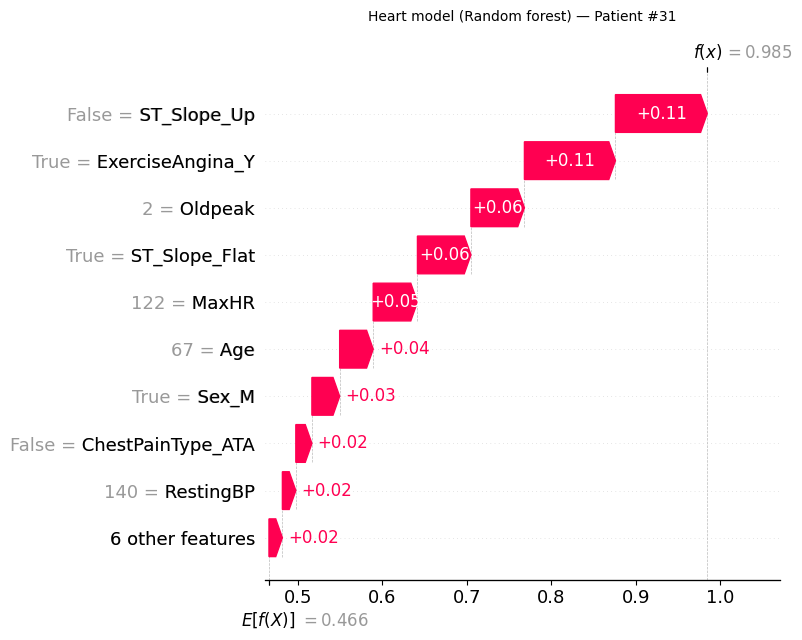


>>> Heart model: most uncertain predictions

Heart model (Random forest) — Patient #22
Feature values:
Age                     61
RestingBP              142
Cholesterol            200
FastingBS                1
MaxHR                  100
Oldpeak                1.5
Sex_M                 True
ChestPainType_ATA    False
ChestPainType_NAP    False
ChestPainType_TA      True
RestingECG_Normal    False
RestingECG_ST         True
ExerciseAngina_Y     False
ST_Slope_Flat        False
ST_Slope_Up          False


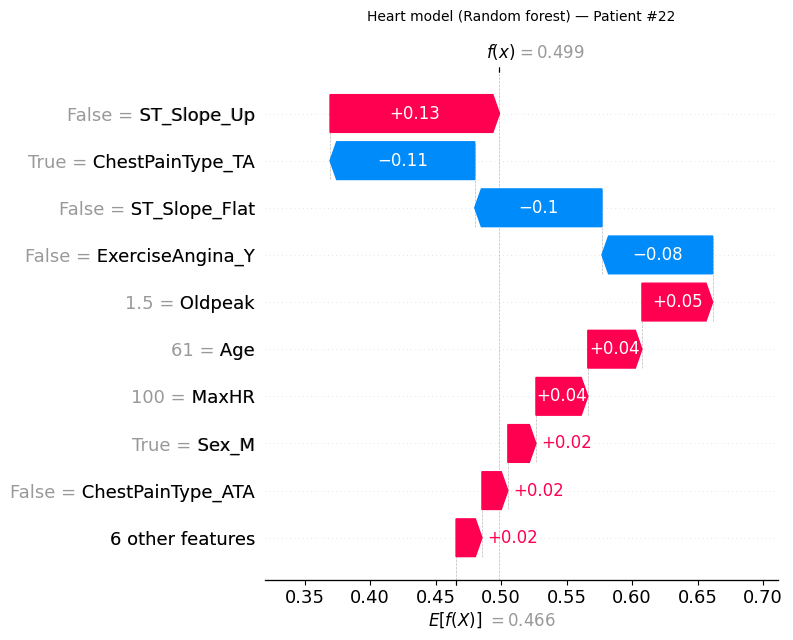


Heart model (Random forest) — Patient #8
Feature values:
Age                     58
RestingBP              150
Cholesterol            270
FastingBS                0
MaxHR                  111
Oldpeak                0.8
Sex_M                 True
ChestPainType_ATA    False
ChestPainType_NAP    False
ChestPainType_TA     False
RestingECG_Normal    False
RestingECG_ST        False
ExerciseAngina_Y      True
ST_Slope_Flat        False
ST_Slope_Up           True


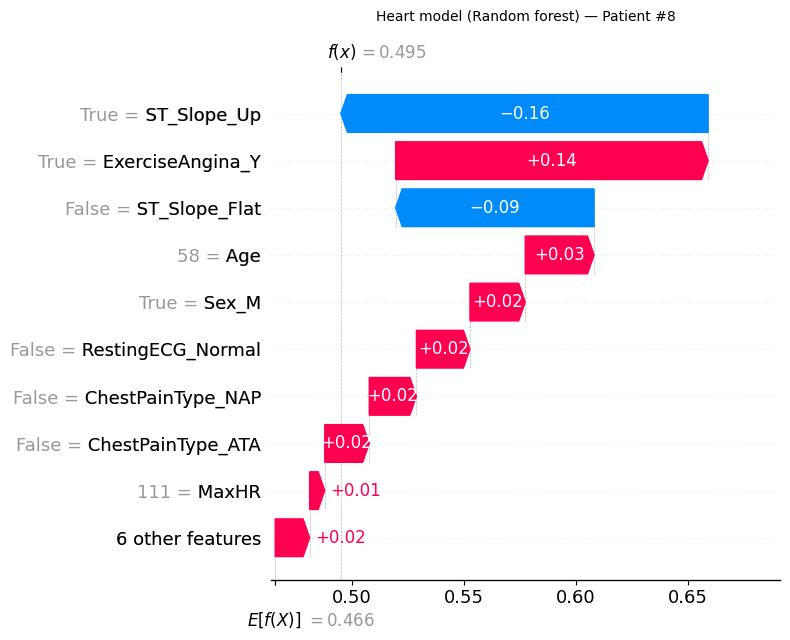


Heart model (Random forest) — Patient #100
Feature values:
Age                     46
RestingBP              142
Cholesterol            177
FastingBS                0
MaxHR                  160
Oldpeak                1.4
Sex_M                False
ChestPainType_ATA    False
ChestPainType_NAP     True
ChestPainType_TA     False
RestingECG_Normal    False
RestingECG_ST        False
ExerciseAngina_Y      True
ST_Slope_Flat        False
ST_Slope_Up          False


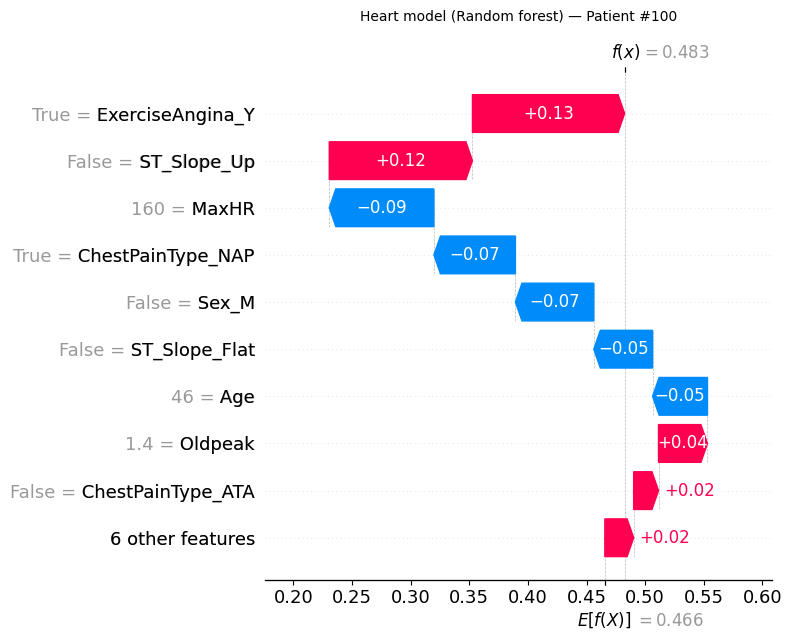


>>> Cardio model: most confident predictions

Cardio model (XGBoost) — Patient #2748
Feature values:
age_years       64.000000
gender           1.000000
height         154.000000
weight          58.000000
ap_hi          150.000000
ap_lo           80.000000
cholesterol      3.000000
gluc             1.000000
smoke            0.000000
alco             0.000000
active           1.000000
bmi             24.456063


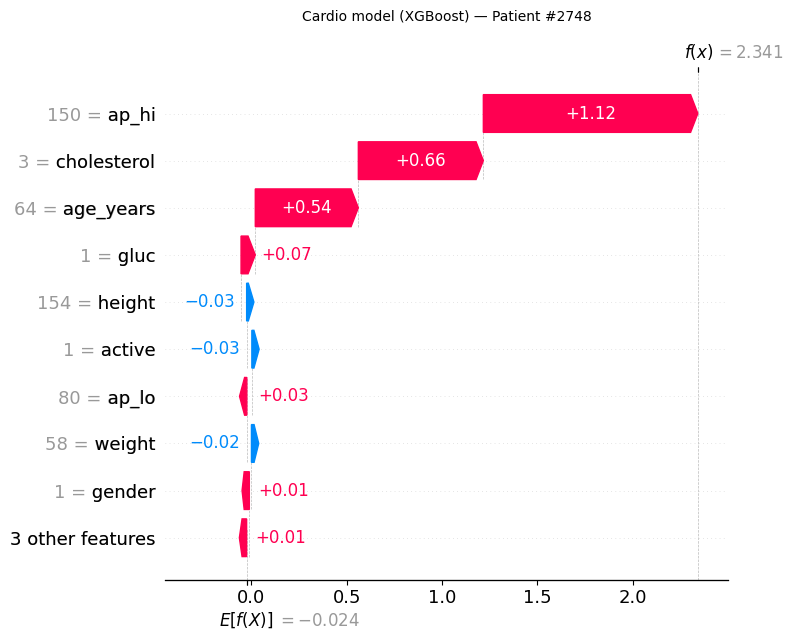


Cardio model (XGBoost) — Patient #7161
Feature values:
age_years       64.000000
gender           1.000000
height         155.000000
weight         104.000000
ap_hi          160.000000
ap_lo           80.000000
cholesterol      3.000000
gluc             1.000000
smoke            0.000000
alco             0.000000
active           1.000000
bmi             43.288241


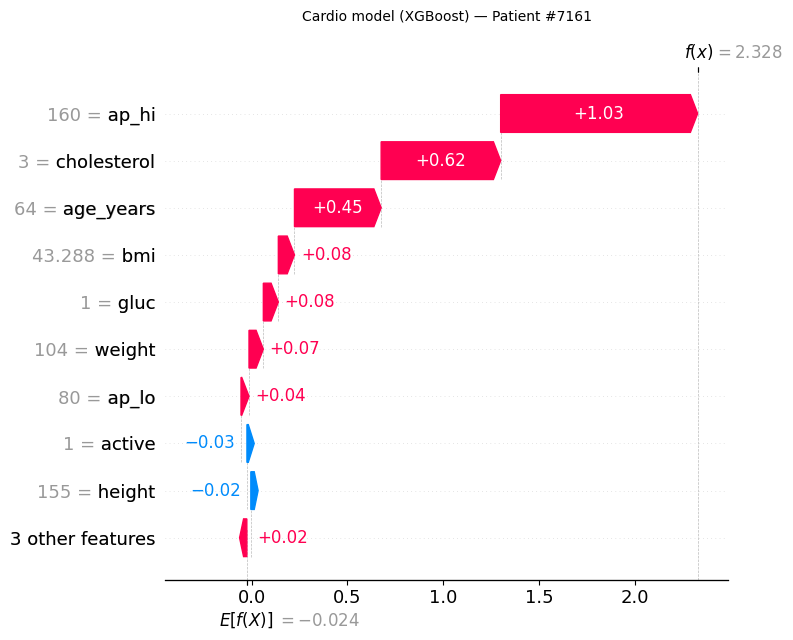


Cardio model (XGBoost) — Patient #2873
Feature values:
age_years       46.000000
gender           2.000000
height         180.000000
weight         114.000000
ap_hi          150.000000
ap_lo          100.000000
cholesterol      2.000000
gluc             1.000000
smoke            1.000000
alco             1.000000
active           0.000000
bmi             35.185185


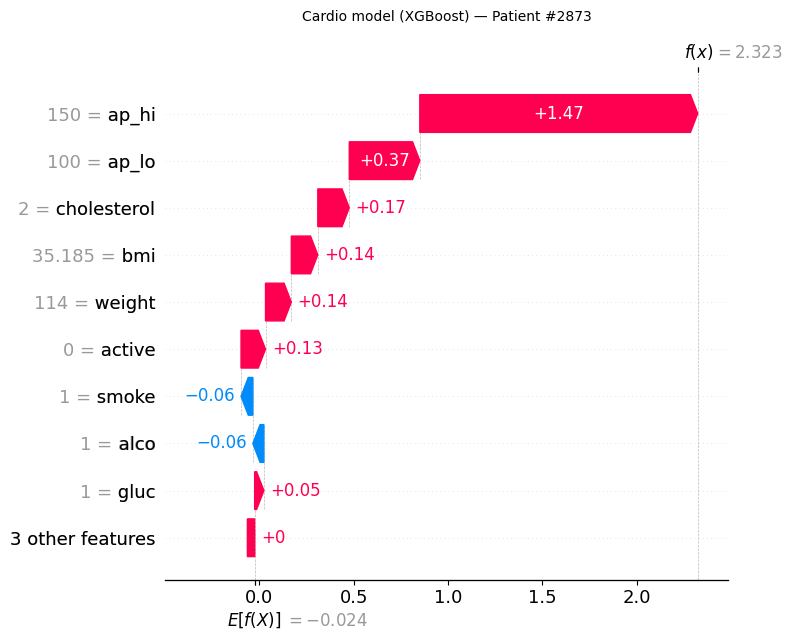


>>> Cardio model: most uncertain predictions

Cardio model (XGBoost) — Patient #5130
Feature values:
age_years       57.000000
gender           1.000000
height         160.000000
weight          55.000000
ap_hi          130.000000
ap_lo           80.000000
cholesterol      1.000000
gluc             1.000000
smoke            0.000000
alco             0.000000
active           0.000000
bmi             21.484375


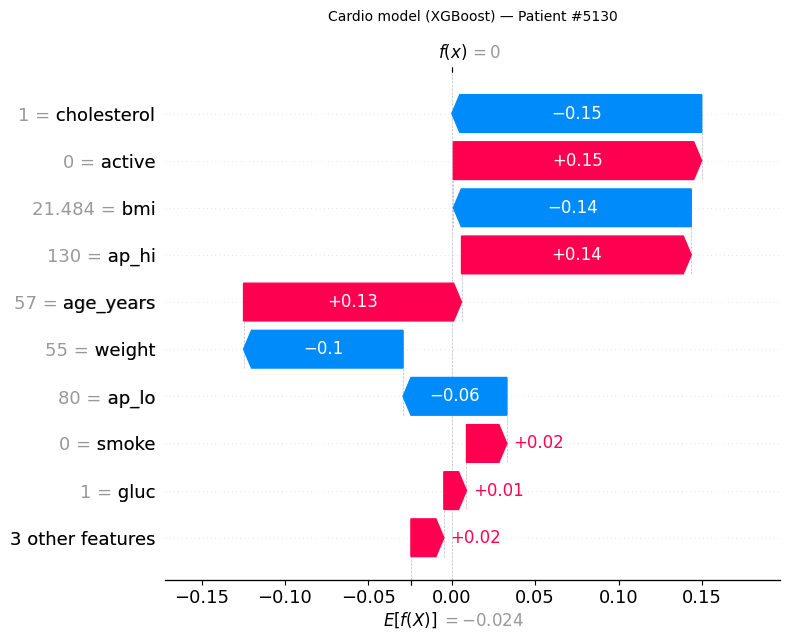


Cardio model (XGBoost) — Patient #3281
Feature values:
age_years       60.000000
gender           2.000000
height         169.000000
weight          78.000000
ap_hi          120.000000
ap_lo           80.000000
cholesterol      1.000000
gluc             1.000000
smoke            0.000000
alco             0.000000
active           0.000000
bmi             27.309968


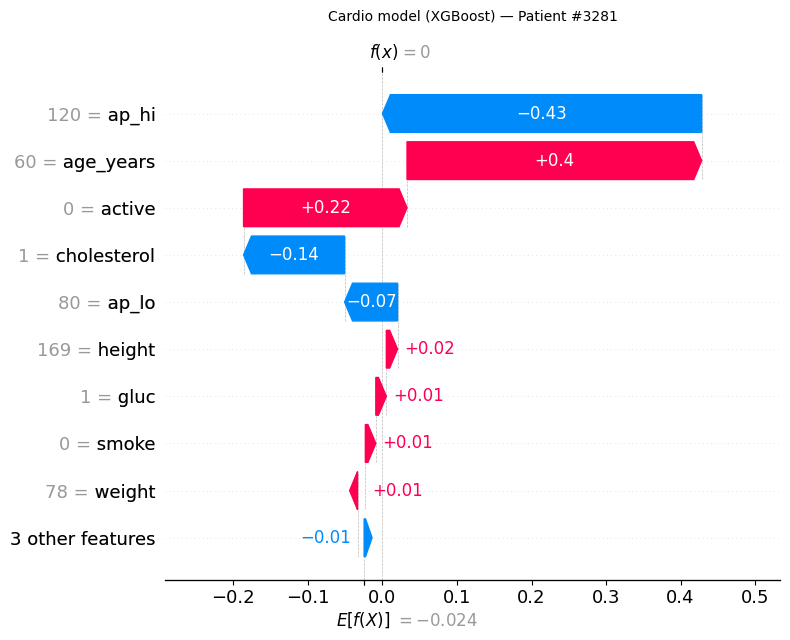


Cardio model (XGBoost) — Patient #9247
Feature values:
age_years       51.000000
gender           2.000000
height         178.000000
weight         107.000000
ap_hi          130.000000
ap_lo           80.000000
cholesterol      1.000000
gluc             1.000000
smoke            0.000000
alco             0.000000
active           1.000000
bmi             33.770989


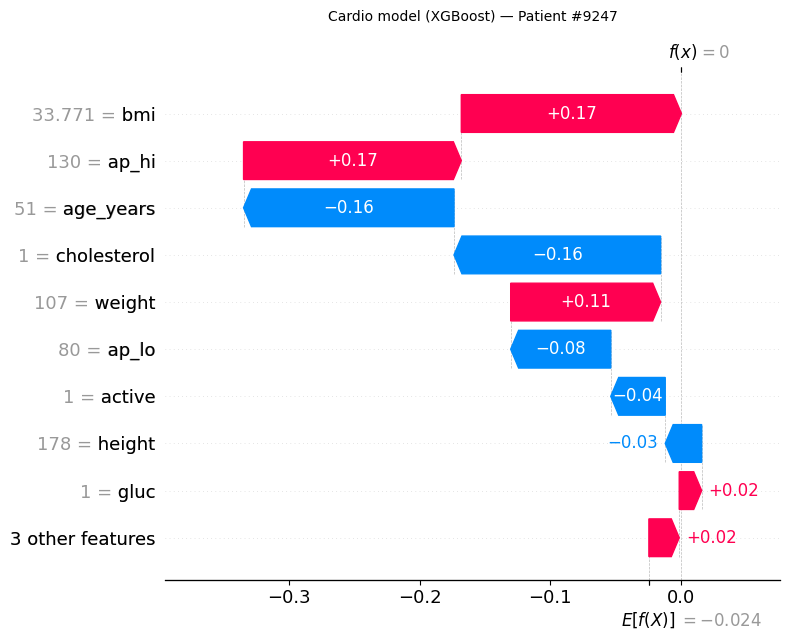

In [55]:
# Step 3: Resolve expected values
# The average prediction the model would make if it knew absolutely nothing about the specific patient's features.

# Heart
if isinstance(explainer_h.expected_value, (list, np.ndarray)):
  ev_heart = explainer_h.expected_value[1]
else:
  ev_heart = explainer_h.expected_value

# Cardio
if isinstance(explainer_c.expected_value, (list, np.ndarray)):
  ev_cardio = explainer_c.expected_value[1]
else:
  ev_cardio = explainer_c.expected_value

# Step 4: Force plots

'''
def show_force_plot(expected_value, shap_vals, patient_row, feature_names, model_name, patient_idx):
  """
  expected_value : scalar base rate
  shap_vals      : 1D array of SHAP values for this patient
  patient_row    : pd.Series with original (readable) feature values
  """
  print(f"\n{'='*60}")
  print(f"{model_name} — Patient #{patient_idx}")
  print(f"{'='*60}")
  print("Feature values:")
  print(patient_row.to_string())

  #plt.figure(figsize=(20, 3))
  shap.force_plot(
      expected_value,
      shap_vals,
      patient_row,
      feature_names=feature_names,
      matplotlib=True,
      show=False,
      text_rotation=15
  )
  plt.title(f"{model_name} — Patient #{patient_idx}", pad=20, fontsize=10)
  plt.tight_layout()
  plt.show()
  plt.close('all')
''' # The force plot is less visible than waterfall plot.

def show_force_plot(expected_value, shap_vals, patient_row, feature_names, model_name, patient_idx):
  print(f"\n{'='*60}")
  print(f"{model_name} — Patient #{patient_idx}")
  print(f"{'='*60}")
  print("Feature values:")
  print(patient_row.to_string())

  # Build a shap.Explanation object (needed for waterfall plot)
  explanation = shap.Explanation(
      values=shap_vals,
      base_values=expected_value,
      data=patient_row.values,
      feature_names=feature_names
  )

  plt.figure(figsize=(10, 8))
  shap.plots.waterfall(explanation, show=False)
  plt.title(f"{model_name} — Patient #{patient_idx}", pad=15, fontsize=10)
  plt.tight_layout()
  plt.show()
  plt.close('all')

# Step 5: Investigate interesting patients

probs_h = rf_heart.predict_proba(X_test_h_scaled)[:, 1]
most_confident_h = np.argsort(probs_h)[-3:][::-1].tolist()
most_uncertain_h = np.argsort(np.abs(probs_h - 0.5))[:3].tolist()

probs_c = best_xgb.predict_proba(X_test_c_scaled)[:, 1]
most_confident_c = np.argsort(probs_c)[-3:][::-1].tolist()
most_uncertain_c = np.argsort(np.abs(probs_c - 0.5))[:3].tolist()

print("Heart  — most confident indices :", most_confident_h)
print("Heart  — most uncertain indices :", most_uncertain_h)
print("Cardio — most confident indices :", most_confident_c)
print("Cardio — most uncertain indices :", most_uncertain_c)

# Step 6: Show force plots

# Heart model — most confident patients
print("\n>>> Heart model: most confident predictions")
for idx in most_confident_h:
  show_force_plot(
      ev_heart,
      sv_heart[idx],
      X_test_h.iloc[idx], # original readable values (not scaled) - like restingBP=140 rather than 0.34
      heart_features,
      "Heart model (Random forest)",
      idx
  )

# Heart model — most uncertain patients
print("\n>>> Heart model: most uncertain predictions")
for idx in most_uncertain_h:
  show_force_plot(
      ev_heart,
      sv_heart[idx],
      X_test_h.iloc[idx],
      heart_features,
      "Heart model (Random forest)",
      idx
  )

# Cardio model — most confident patients
print("\n>>> Cardio model: most confident predictions")
for idx in most_confident_c:
  # pass original unscaled values so the display is readable
  show_force_plot(
      ev_cardio,
      sv_cardio[idx],
      X_test_c.iloc[idx], # original unscaled cardio values
      cardio_features,
      "Cardio model (XGBoost)",
      idx
  )

# Cardio model — most uncertain patients
print("\n>>> Cardio model: most uncertain predictions")
for idx in most_uncertain_c:
  show_force_plot(
      ev_cardio,
      sv_cardio[idx],
      X_test_c.iloc[idx],
      cardio_features,
      "Cardio model (XGBoost)",
      idx
  )

The waterfall plots illustrate a clear distinction between the model's confident and uncertain predictions for both heart and cardio models, by highlighting the net effect of features on the model's confidence.

In confident predictions, we observe a unified aspect among the features. The plot is dominated by a single color (typically red for high-risk patients), indicating that the majority of clinical markers are providing synergistic signals to push the probability toward a definitive classification.

We also see a significant difference between the base value (the dataset average - E[f(X)]) and the final output (f(x)), indicating that the specific patient's markers have pulled the model far from its default stance.

Conversely, uncertain predictions show a mix of colors and directions. These plots show a nearly equal distribution of red and blue bars, where positive risk factors are effectively neutralized by protective factors. This contradictory feature attribution explains why the model cannot reach a high-probability conclusion, as the clinical evidence for and against the diagnosis is balanced.

Also, we see a final output that remains very close to the base value. This suggests that the patient's data lacks strong distinguishing characteristics, or that the risk factors present are perfectly counterbalanced by protective ones, leaving the model in a state of neutral indecision.

In [56]:
# To save models
joblib.dump(rf_heart, 'heart_rf_model.joblib')
joblib.dump(scaler_h, 'heart_scaler.joblib')
joblib.dump(best_xgb, 'cardio_xgb_model.joblib')
joblib.dump(scaler_c, 'cardio_scaler.joblib')

print("All models and scalers saved successfully.")
print("Files to upload to GitHub:")
for f in ['heart_rf_model.joblib', 'heart_scaler.joblib', 'cardio_xgb_model.joblib', 'cardio_scaler.joblib']:
  print(f"  {f}")

All models and scalers saved successfully.
Files to upload to GitHub:
  heart_rf_model.joblib
  heart_scaler.joblib
  cardio_xgb_model.joblib
  cardio_scaler.joblib
